# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [ ]:
#Installing the libraries with the specified versions
#!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

#Packages already installed in vscode local environment.

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [4]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [9]:
# Load the dataset
kart = pd.read_csv("../data/SuperKart.csv")

# copying data to another variable to avoid any changes to original data
data = kart.copy()

# **Data Overview**

## View the first and last 5 rows of the dataset

In [12]:
data.head(5)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [13]:
data.tail(5)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


## Check the data types of the columns for the dataset

In [14]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   str    
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   str    
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   str    
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   str    
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   str    
 9   Store_Location_City_Type   8763 non-null   str    
 10  Store_Type                 8763 non-null   str    
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 821.7 KB


**Let's check the statistical summary of the data.**

In [15]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD6114,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

In [18]:
# checking for missing values in the data
data.isnull().sum() 

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [19]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

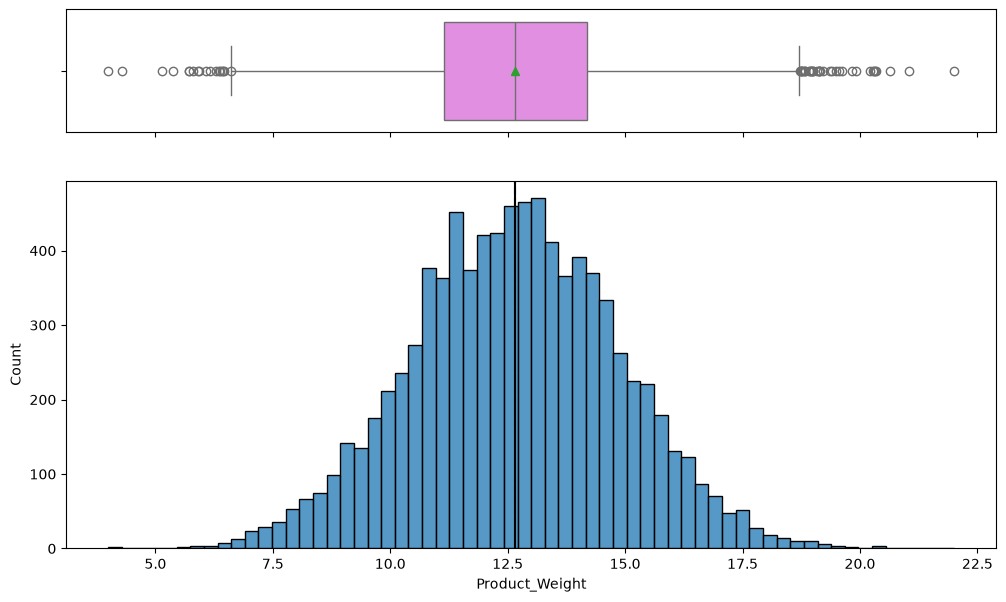

In [20]:
histogram_boxplot(data, "Product_Weight")

* Product weight is approximately normally distributed.
* Most products have weights between 11 and 14 units.
* A few low and high weight outliers are present.
* Mean and median are very close, indicating a nearly symmetric distribution.

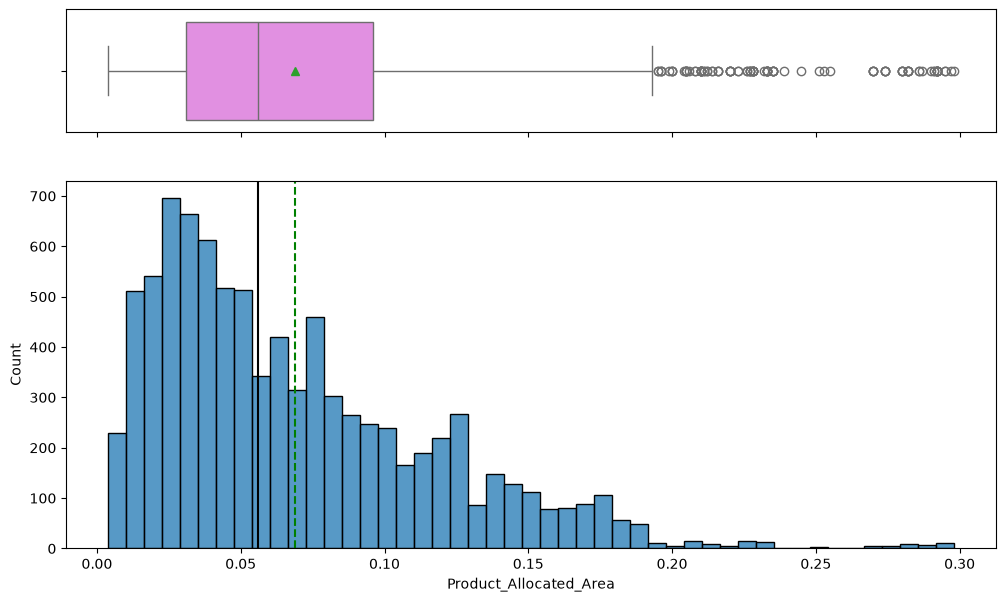

In [21]:
histogram_boxplot(data, "Product_Allocated_Area") #Complete the code to plot the boxplot and histogram of Product_Allocated_Area

* The distribution is positively (right) skewed.
* Most products occupy a relatively small allocated area.
* Several high-value outliers are observed.
* Mean is greater than the median due to the right skew.

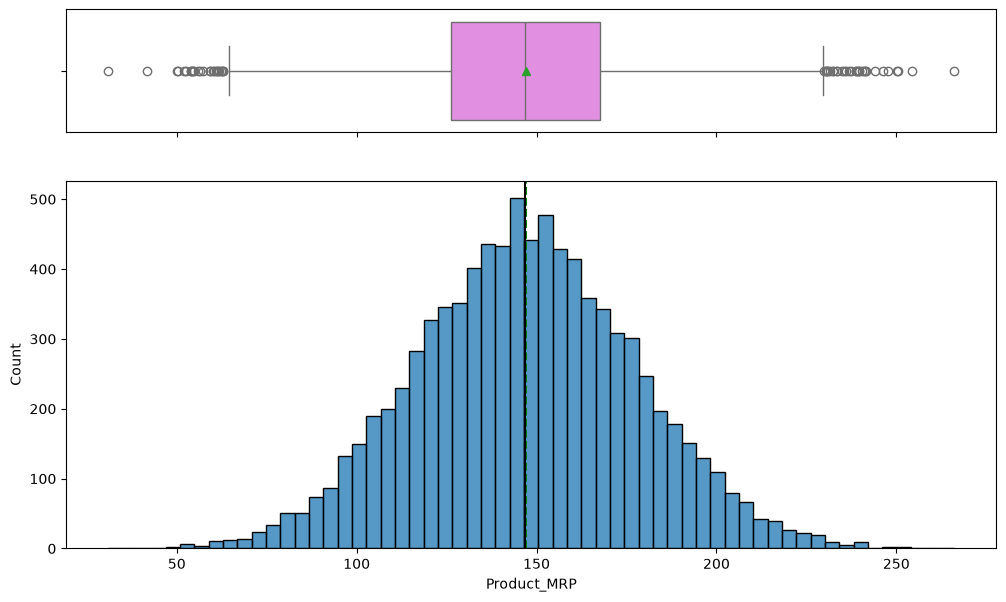

In [22]:
histogram_boxplot(data, "Product_MRP") #Complete the code to plot the boxplot and histogram of Product_MRP

* Product MRP follows an approximately normal distribution.
* Most product prices lie between 120 and 170.
* A few unusually low and high priced products exist.
* Mean and median are close, indicating limited skewness.

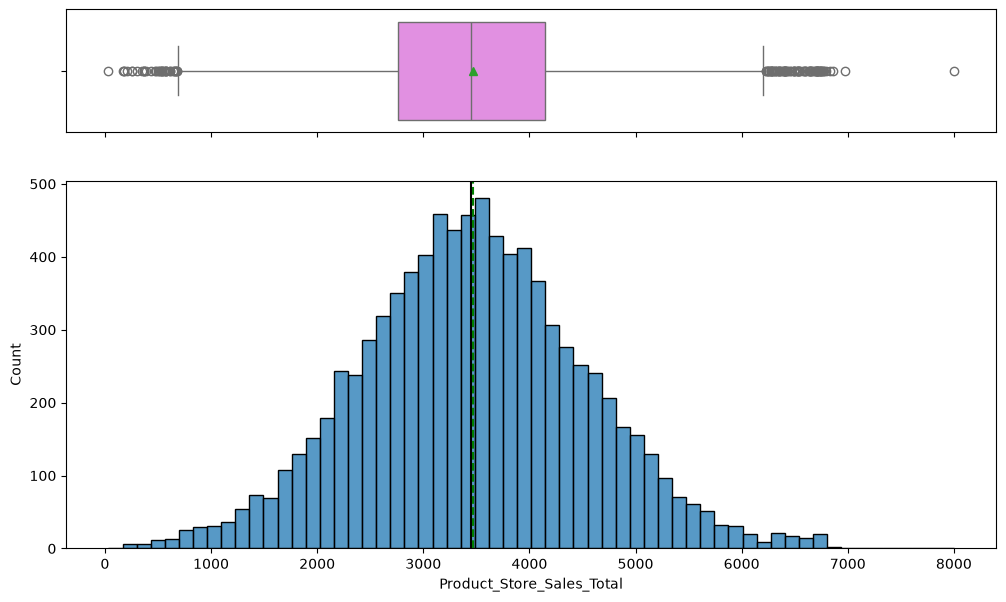

In [23]:
histogram_boxplot(data, "Product_Store_Sales_Total") #Complete the code to plot the boxplot and histogram of Product_Store_Sales_Total

* Sales are approximately bell-shaped with slight right skewness.
* Most products generate sales between 2,500 and 4,500.
* Both low and high sales outliers are present.
* The target variable does not require transformation based solely on its distribution.

In [24]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

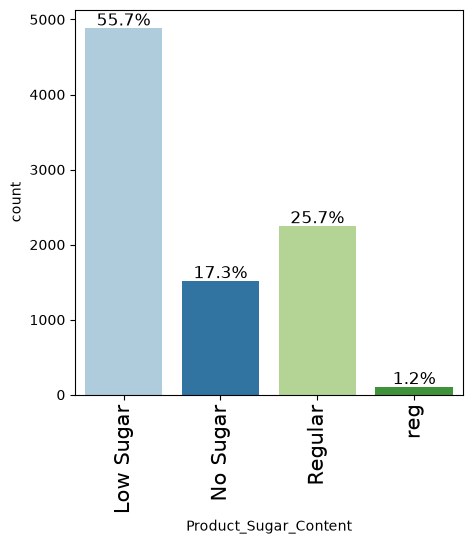

In [25]:
labeled_barplot(data, "Product_Sugar_Content", perc=True)

* Low Sugar products dominate the dataset (55.7%).
* Regular sugar products account for approximately 25.7%.
* No Sugar products represent about 17.3%.
* The 'reg' category contributes only 1.2%, indicating a possible data entry inconsistency.

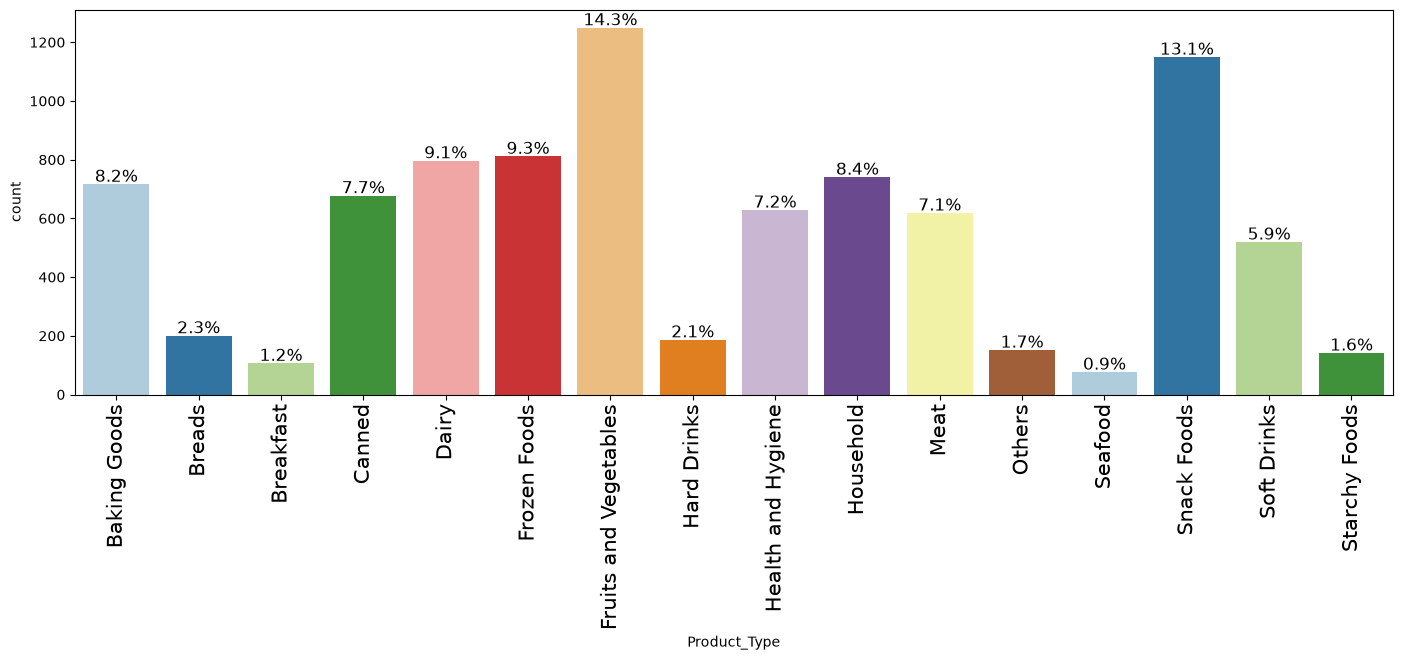

In [26]:
labeled_barplot(data, "Product_Type", perc=True) #Complete the code to plot the labelled barplot of Product_Type with the percentages being displayed

* Product categories are fairly diverse.
* Fruits and Vegetables (14.3%) and Snack Foods have the highest representation.
* Categories such as Seafood, Breakfast, and Starchy Foods have comparatively fewer observations.
* The dataset contains a balanced mix of different product categories.

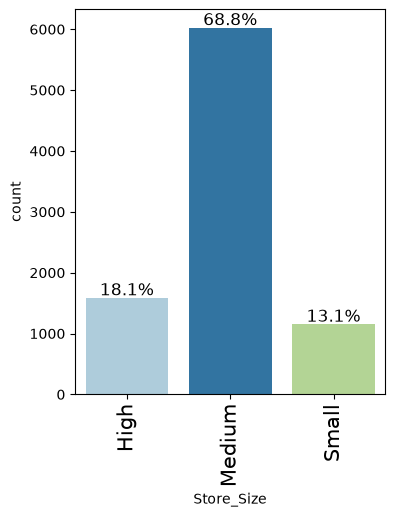

In [27]:
labeled_barplot(data, "Store_Size", perc=True) #Complete the code to plot the labelled barplot of Store_Id with the percentages being displayed

* Most stores are Medium-sized (68.8%).
* High-sized stores account for 18.1%.
* Small stores make up 13.1%.
* The dataset is dominated by medium-sized stores.

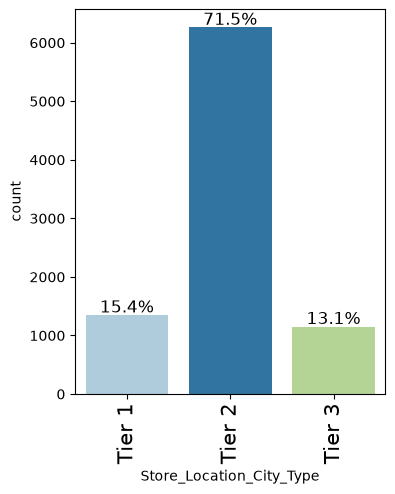

In [28]:
labeled_barplot(data, "Store_Location_City_Type", perc=True) #Complete the code to plot the labelled barplot of Store_Size with the percentages being displayed

* Tier 2 cities account for the majority (71.5%) of stores.
* Tier 1 contributes 15.4%.
* Tier 3 contributes 13.1%.
* The dataset is heavily concentrated in Tier 2 locations.

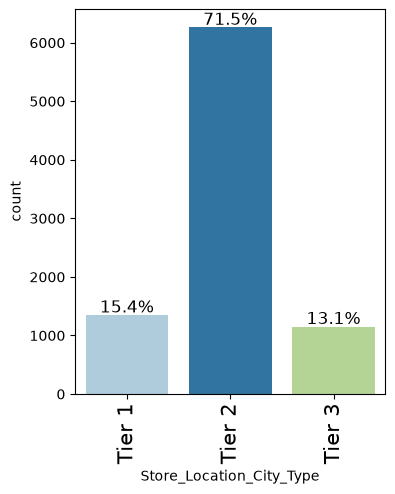

In [29]:
labeled_barplot(data, "Store_Location_City_Type", perc=True)  #Complete the code to plot the labelled barplot of Store_Location_City_Type with the percentages being displayed

* Tier 2 cities account for the majority (71.5%) of stores.
* Tier 1 contributes 15.4%.
* Tier 3 contributes 13.1%.
* The dataset is heavily concentrated in Tier 2 locations.

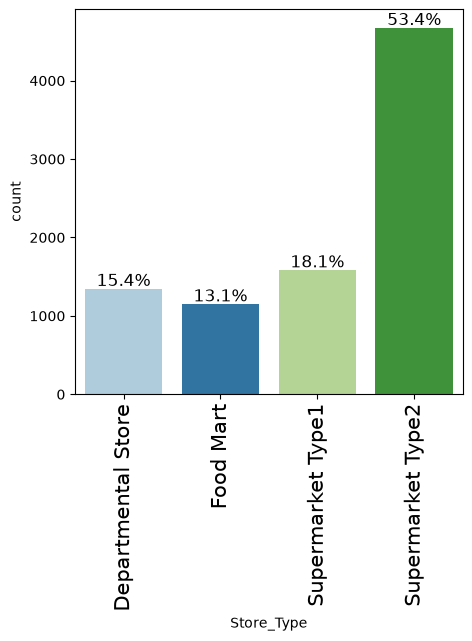

In [30]:
labeled_barplot(data, "Store_Type", perc=True) #Complete the code to plot the labelled barplot of Store_Type with the percentages being displayed

* Supermarket Type2 is the most common store format (53.4%).
* Supermarket Type1 contributes 18.1%.
* Department Stores account for 15.4%.
* Food Marts contribute 13.1%.

**Overall Univariate Summary**
* Numerical variables are mostly close to normally distributed, with Product_Allocated_Area showing noticeable right skewness.
* Several numerical variables contain outliers, but they appear to represent natural business variation rather than obvious data errors.
* The dataset contains no missing values or duplicate records.
* Most categorical variables show moderate class imbalance, particularly Store Size, Store Location, and Store Type.

## Bivariate Analysis

**Correlation Matrix**

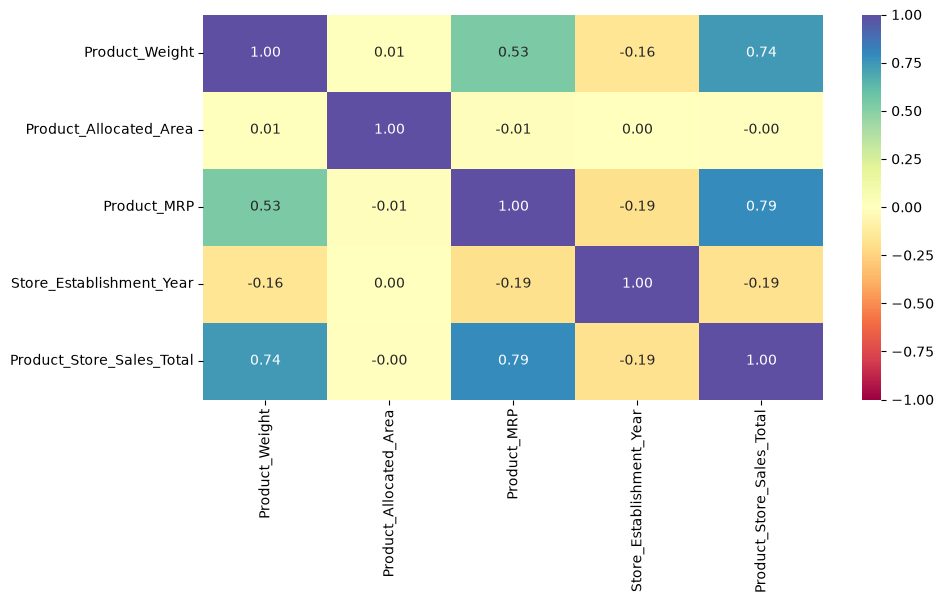

In [31]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(),
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cmap="Spectral"
)
plt.show()

### **Observations**

* **Product_MRP** has the **highest positive correlation (0.79)** with **Product_Store_Sales_Total**, indicating that products with higher selling prices generally generate higher sales.

* **Product_Weight** also shows a **strong positive correlation (0.74)** with **Product_Store_Sales_Total**, suggesting that heavier products tend to have higher sales values.

* **Product_Weight** and **Product_MRP** have a **moderate positive correlation (0.53)**, indicating that heavier products are generally priced higher.

* **Product_Allocated_Area** has **almost no correlation** with any other numerical feature, suggesting that the shelf space allocated to a product has little direct relationship with its price or sales.

* **Store_Establishment_Year** has a **weak negative correlation** with **Product_MRP** and **Product_Store_Sales_Total** (approximately **-0.19**), indicating that store age has minimal influence on product pricing or sales.

* No pair of numerical variables exhibits **very high correlation (>|0.90|)**, indicating that multicollinearity is not a significant concern among the numerical features.

### **Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the numeric columns**

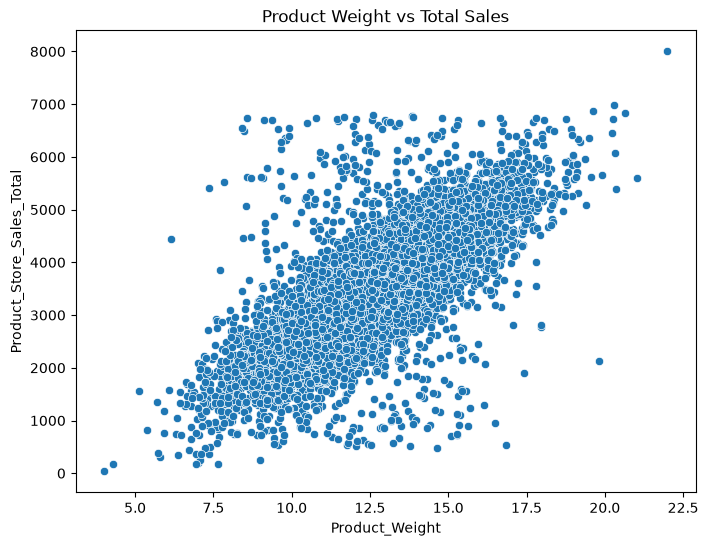

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=data["Product_Weight"],
    y=data["Product_Store_Sales_Total"]
)

plt.title("Product Weight vs Total Sales")
plt.show()

### **Observations**

* There is a **clear positive relationship** between **Product_Weight** and **Product_Store_Sales_Total**, indicating that heavier products generally generate higher sales.

* The points follow an **upward trend**, supporting the positive correlation observed in the heatmap (**0.74**).

* Although the relationship is strong, there is **considerable variability** in sales for products with similar weights, suggesting that **Product_Weight alone is not sufficient to explain sales**.

* A few **outliers** are visible with exceptionally high sales, but they are limited in number and do not alter the overall positive trend.

* This indicates that **Product_Weight** is an important predictor of sales and is likely to contribute meaningfully during model building.

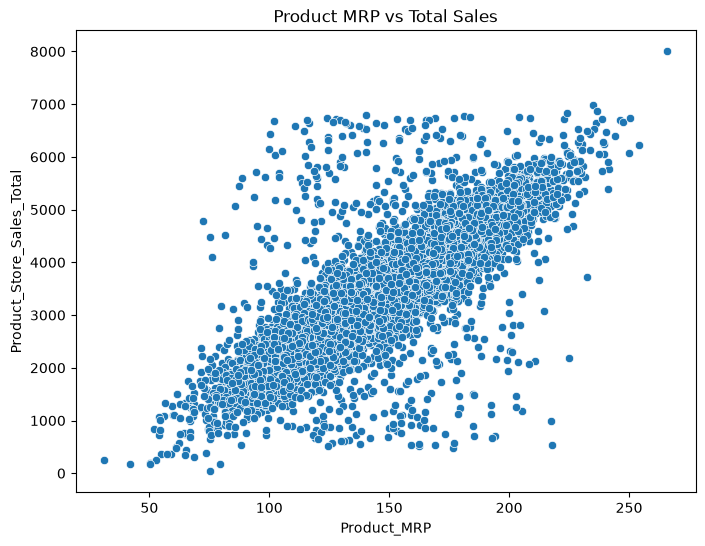

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=data["Product_MRP"],
    y=data["Product_Store_Sales_Total"]
)

plt.title("Product MRP vs Total Sales")
plt.show()

### **Observations**

* There is a **strong positive relationship** between **Product_MRP** and **Product_Store_Sales_Total**, indicating that products with higher MRP generally achieve higher total sales.

* The data points form a **clear upward trend**, confirming the strong positive correlation (**0.79**) observed in the correlation heatmap.

* Although sales generally increase with product price, there is **some variation** among products with similar MRP values, suggesting that factors other than MRP also influence sales.

* A few **high-sales outliers** are present, but they do not significantly affect the overall positive trend.

* **Product_MRP** appears to be one of the **most important numerical features** for predicting **Product_Store_Sales_Total** and is expected to contribute significantly during model building.

### **Let us see from which product type the company is generating most of the revenue**

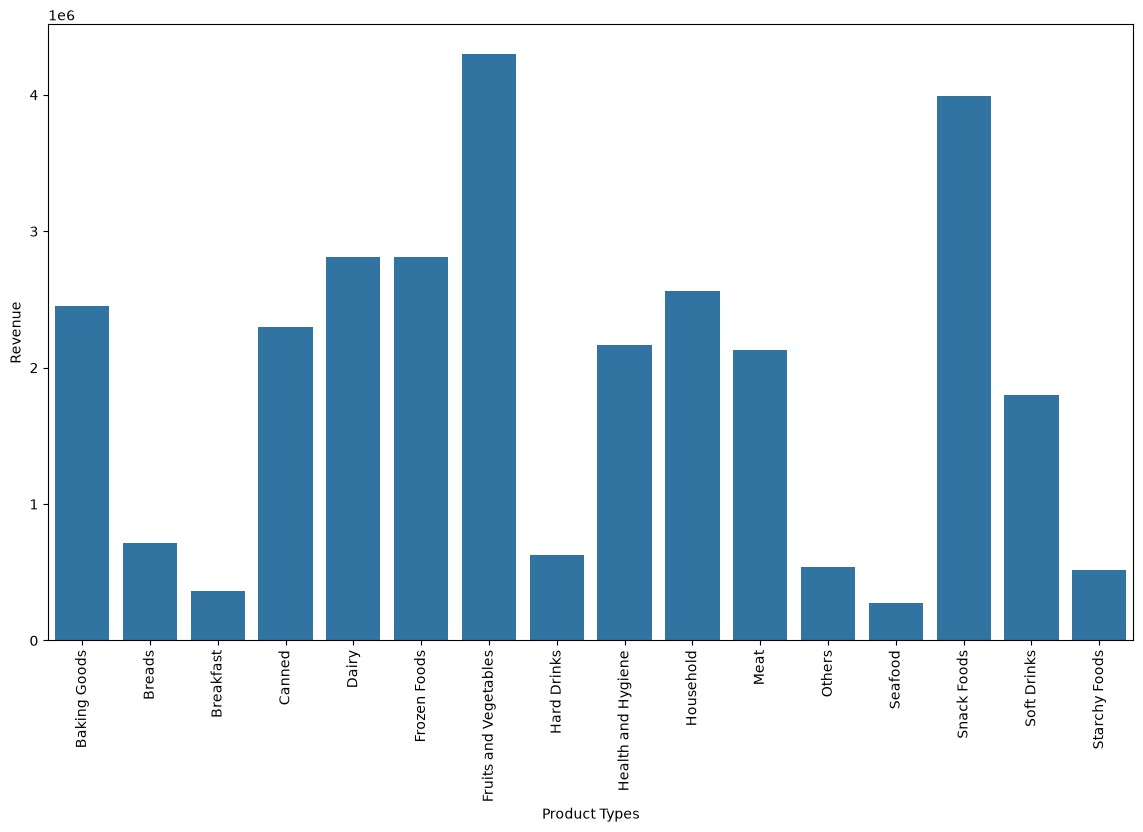

In [36]:
df_revenue1 = data.groupby(["Product_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()

plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)

a = sns.barplot(
    x=df_revenue1.Product_Type,
    y=df_revenue1.Product_Store_Sales_Total
)

a.set_xlabel("Product Types")
a.set_ylabel("Revenue")

plt.show()

### **Observations**

* **Fruits and Vegetables** generated the **highest total revenue** among all product categories.

* **Snack Foods** contributed the **second-highest total sales**, indicating consistently strong customer demand.

* **Frozen Foods**, **Dairy**, **Household**, and **Baking Goods** also generated substantial revenue, making them important contributors to overall sales.

* Categories such as **Seafood**, **Breakfast**, **Starchy Foods**, **Others**, and **Hard Drinks** contributed comparatively lower total revenue.

* The large differences in total revenue may be influenced by both the **number of products available** in each category and their **individual sales performance**. Therefore, total revenue alone should not be interpreted as product popularity.

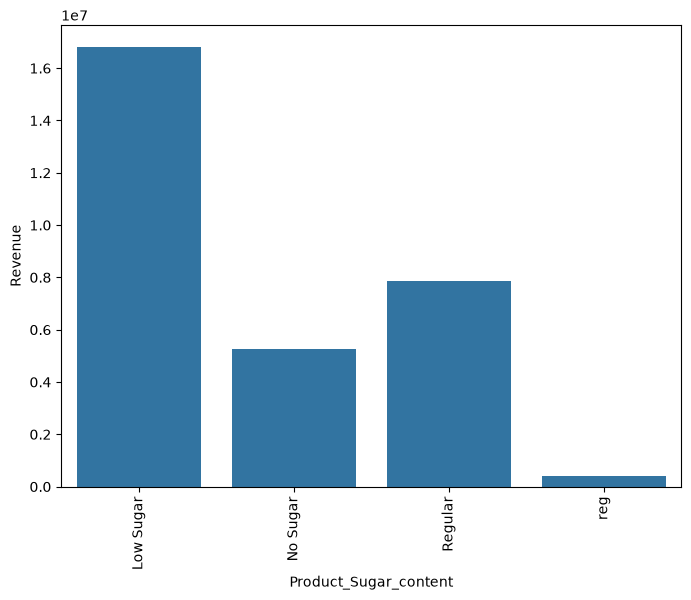

In [43]:
#see revenue by sugar content in product
df_revenue2 = data.groupby(["Product_Sugar_Content"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()

plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)

b = sns.barplot(
    x=df_revenue2.Product_Sugar_Content,
    y=df_revenue2.Product_Store_Sales_Total
)

b.set_xlabel("Product_Sugar_content")
b.set_ylabel("Revenue")

plt.show()

### **Observations**

* **Low Sugar** products generated the **highest total revenue** among all sugar content categories.

* **Regular** sugar products contributed the **second-highest revenue**.

* **No Sugar** products generated considerably lower revenue than both Low Sugar and Regular products.

* The **'reg'** category contributed the **lowest revenue**, suggesting it may represent a small number of products or a data-entry inconsistency.

* Since these values represent **total revenue**, the differences may also be influenced by the number of products available in each sugar-content category rather than individual product performance.

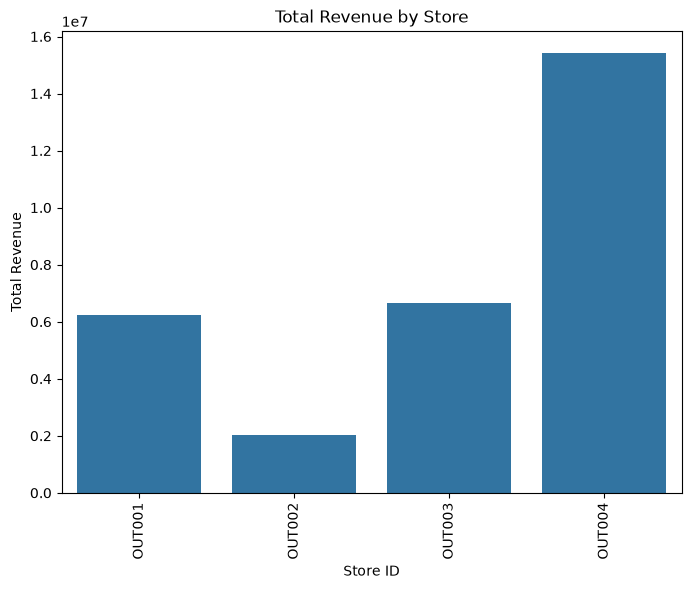

In [44]:
# Calculate total revenue generated by each store
df_store_revenue = data.groupby("Store_Id", as_index=False)[
    "Product_Store_Sales_Total"
].sum()

# Plot total revenue for each store
plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_store_revenue,
    x="Store_Id",
    y="Product_Store_Sales_Total"
)

plt.xlabel("Store ID")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Store")
plt.xticks(rotation=90)

plt.show()

### **Observations**

* **Store OUT004** generated the **highest total revenue** among all stores, significantly outperforming the other three stores.

* **OUT003** recorded the **second-highest total revenue**, followed closely by **OUT001**.

* **OUT002** generated the **lowest total revenue**, indicating comparatively lower sales performance.

* The substantial difference in total revenue suggests that **OUT004** may have a larger customer base, greater product availability, or higher sales volume than the other stores.

* Since the chart represents **total revenue**, the differences may also be influenced by factors such as the number of products sold, inventory size, or store capacity. Therefore, total revenue alone should not be used to compare the operational efficiency of individual stores.

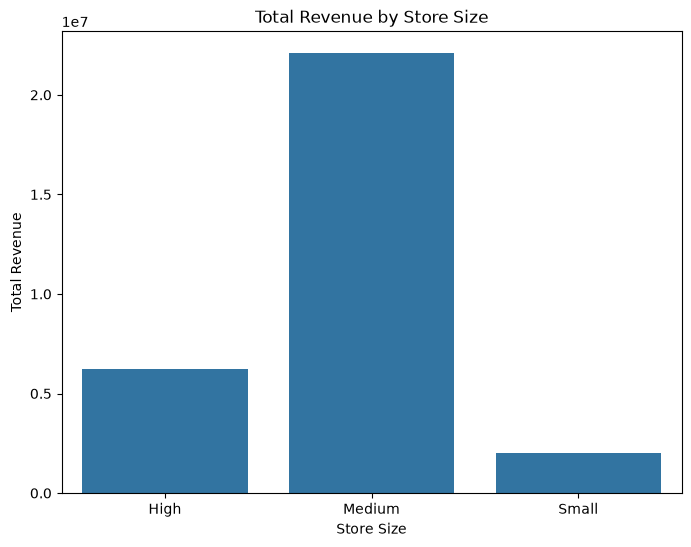

In [41]:
# Calculate total revenue by store size
df_revenue3 = data.groupby("Store_Size", as_index=False)[
    "Product_Store_Sales_Total"
].sum()

# Plot total revenue by store size
plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_revenue3,
    x="Store_Size",
    y="Product_Store_Sales_Total"
)

plt.xlabel("Store Size")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Store Size")

plt.show()

### **Observations**

* **Medium-sized stores** generated the **highest total revenue**, contributing significantly more than both large and small stores.

* **High-sized stores** recorded the **second-highest total revenue**, although the gap between High and Medium stores is substantial.

* **Small-sized stores** generated the **lowest total revenue**, indicating comparatively lower sales.

* The strong performance of **Medium-sized stores** suggests that they may have an optimal combination of product assortment, customer traffic, and operational efficiency.

* Since the chart represents **total revenue**, these differences may also be influenced by the number of stores in each size category. Therefore, total revenue alone should not be used to determine which store size is inherently more profitable.

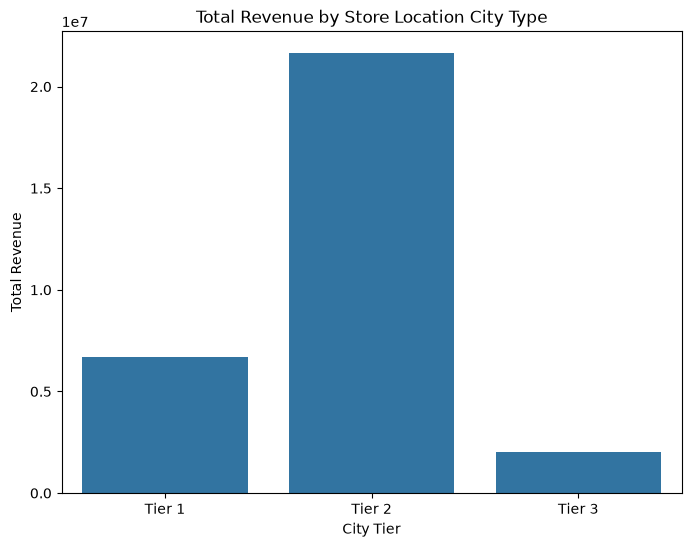

In [42]:
# Calculate total revenue by city tier
df_revenue4 = data.groupby("Store_Location_City_Type", as_index=False)[
    "Product_Store_Sales_Total"
].sum()

# Plot total revenue by city tier
plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_revenue4,
    x="Store_Location_City_Type",
    y="Product_Store_Sales_Total"
)

plt.xlabel("City Tier")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Store Location City Type")

plt.show()

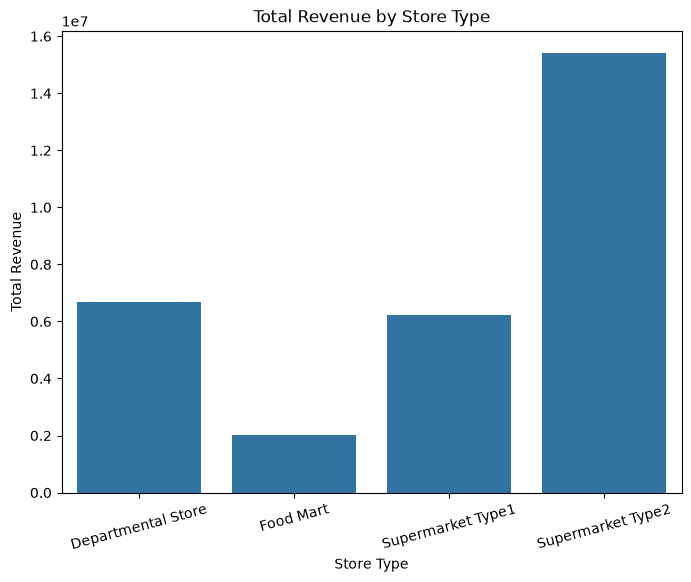

In [45]:
# Calculate total revenue by store type
df_revenue5 = data.groupby("Store_Type", as_index=False)[
    "Product_Store_Sales_Total"
].sum()

# Plot total revenue by store type
plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_revenue5,
    x="Store_Type",
    y="Product_Store_Sales_Total"
)

plt.xlabel("Store Type")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Store Type")

plt.xticks(rotation=15)

plt.show()

### **Observations: Total Revenue by Store Type**

* **Supermarket Type2** generates the **highest total revenue** among all store types, making it the largest contributor to overall sales.

* **Departmental Store** and **Supermarket Type1** generate **moderate levels of revenue**, with Departmental Stores performing slightly better than Supermarket Type1.

* **Food Mart** contributes the **lowest total revenue**, indicating comparatively weaker sales performance.

* The variation in total revenue across store types suggests that **store type has a significant impact on overall sales performance**.

* Overall, **Supermarket Type2 appears to be the most profitable store format** in terms of total revenue generated.

### **Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the other categorical columns**

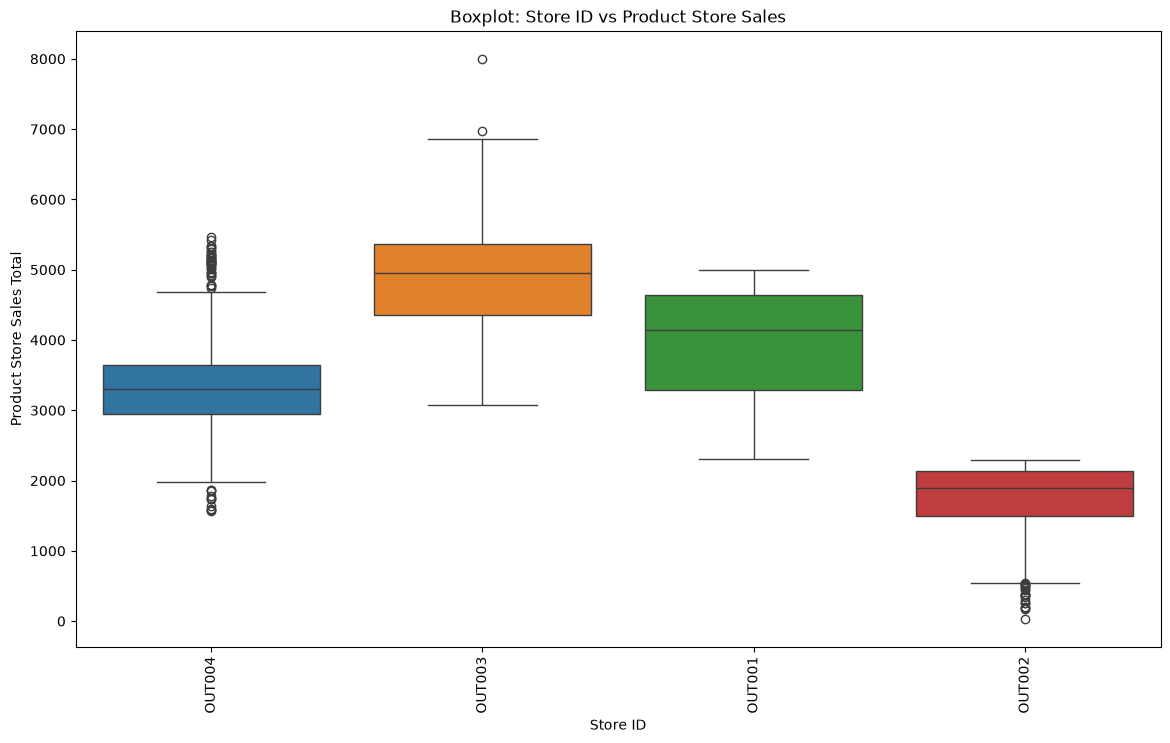

In [46]:
plt.figure(figsize=[14, 8])

sns.boxplot(
    data=data,
    x="Store_Id",
    y="Product_Store_Sales_Total",
    hue="Store_Id"
)

plt.xticks(rotation=90)
plt.title("Boxplot: Store ID vs Product Store Sales")
plt.xlabel("Store ID")
plt.ylabel("Product Store Sales Total")
plt.show()

### **Observations: Store ID vs Product Store Sales**

* **OUT003** has the **highest median product sales**, indicating that products sold in this store generally achieve higher sales than those in other stores.

* **OUT002** has the **lowest median product sales**, suggesting that products in this store generate comparatively lower sales.

* **OUT001** also performs well, with a median sales value lower than OUT003 but higher than OUT004 and OUT002.

* **OUT004** shows **moderate median sales** along with several outliers, indicating that while most products have average sales, a few products perform exceptionally well.

* **OUT003** exhibits the **largest variability** in product sales, whereas **OUT002** has a relatively narrower spread, indicating more consistent but lower sales.

* The presence of outliers across multiple stores suggests that a few products generate exceptionally high or low sales regardless of the store.

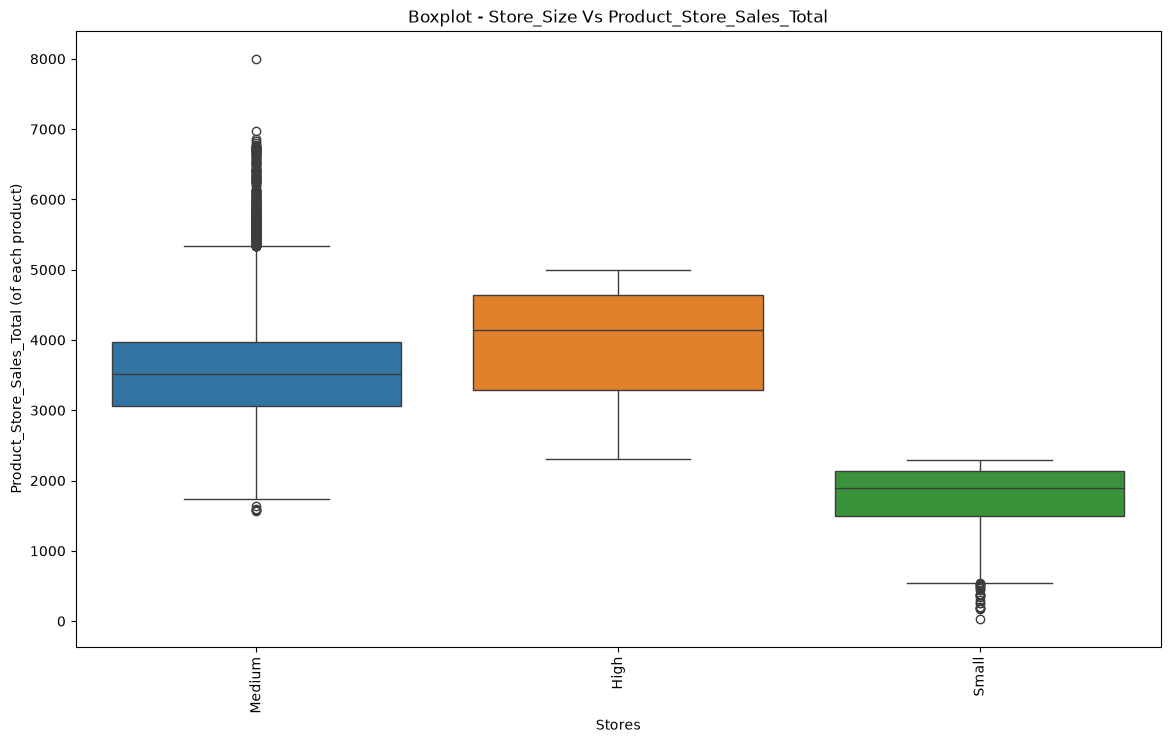

In [48]:
# Create a boxplot to compare the distribution of Product Store Sales across 
# different Store Sizes.
plt.figure(figsize=[14, 8])

sns.boxplot(
    data=data,
    x="Store_Size",
    y="Product_Store_Sales_Total",
    hue="Store_Size"
)

plt.xticks(rotation=90)
plt.title("Boxplot - Store_Size Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

### **Observations: Store Size vs Product Store Sales**

* **High-sized stores** have the **highest median product sales**, indicating that products sold in larger stores generally achieve higher sales.

* **Medium-sized stores** show **moderate product sales** with a large number of high-value outliers, suggesting that several products perform exceptionally well in these stores.

* **Small-sized stores** have the **lowest median product sales**, indicating comparatively lower sales across most products.

* **Medium-sized stores** exhibit the **highest variability** in product sales due to the presence of numerous outliers, whereas **Small-sized stores** have a relatively narrower distribution.

* Outliers are present across all store sizes, especially for **Medium-sized stores**, indicating that a few products generate significantly higher sales than the majority.

* Overall, **store size appears to influence product sales**, with larger stores generally selling products at higher values than smaller stores.

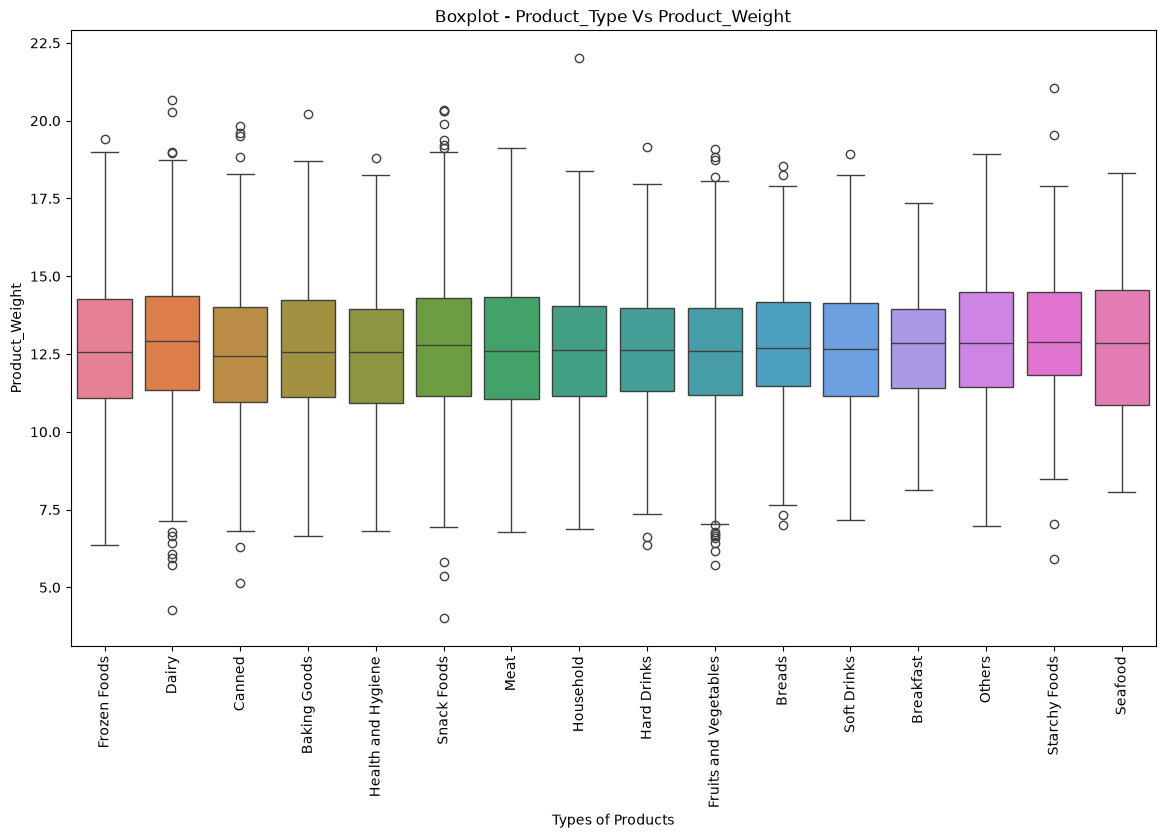

In [ ]:
# Create a boxplot to compare the distribution of Product Weight 
# across different Product Types.

plt.figure(figsize=[14, 8])

sns.boxplot(
    data=data,
    x="Product_Type",
    y="Product_Weight",
    hue="Product_Type"
)

plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_Weight")
plt.xlabel("Types of Products")
plt.ylabel("Product_Weight")

plt.show()

### **Observations: Product Type vs Product Weight**

* The **median product weight** is fairly similar across all product categories, indicating that most product types have comparable weight distributions.

* **Seafood, Starchy Foods, Breakfast, and Others** appear to have slightly higher median product weights compared to several other product categories.

* **Frozen Foods, Canned, Dairy, and Fruits and Vegetables** exhibit moderate product weights with distributions similar to the overall dataset.

* Most product categories show a **comparable spread (IQR)**, suggesting that the variability in product weight is consistent across different product types.

* Several product categories contain **outliers** on both the lower and higher ends of the weight range, indicating the presence of unusually light or heavy products within those categories.

* Overall, **Product Type does not appear to have a strong influence on Product Weight**, as the distributions are largely similar across categories.

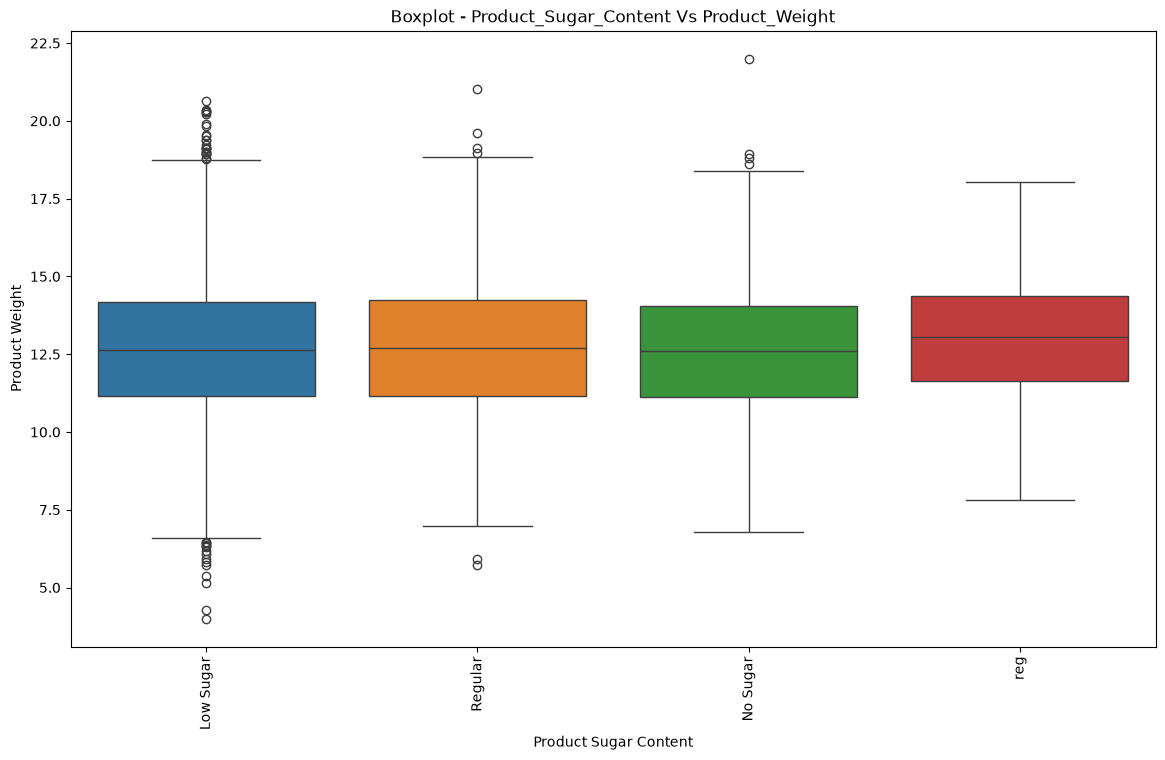

In [ ]:
# Create a boxplot to compare the distribution of Product Weight 
# across different Product Sugar Content categories.

plt.figure(figsize=[14, 8])

sns.boxplot(
    data=data,
    x="Product_Sugar_Content",
    y="Product_Weight",
    hue="Product_Sugar_Content"
)

plt.xticks(rotation=90)
plt.title("Boxplot - Product_Sugar_Content Vs Product_Weight")
plt.xlabel("Product Sugar Content")
plt.ylabel("Product Weight")

plt.show()

### **Observations: Product Sugar Content vs Product Weight**

* The **median product weight** is very similar across all sugar content categories, indicating that sugar content does not have a significant impact on product weight.

* Products labeled **'reg'** have a slightly higher median weight compared to the other sugar content categories.

* **Low Sugar**, **Regular**, and **No Sugar** products exhibit similar distributions, with comparable interquartile ranges (IQRs).

* The **Low Sugar** category contains the highest number of outliers on both the lower and higher ends, indicating the presence of unusually light and heavy products.

* **Regular** and **No Sugar** categories also contain a few outliers, while the **'reg'** category has relatively fewer extreme values.

* Overall, **Product Sugar Content does not appear to have a strong relationship with Product Weight**, as the distributions are largely similar across all categories.

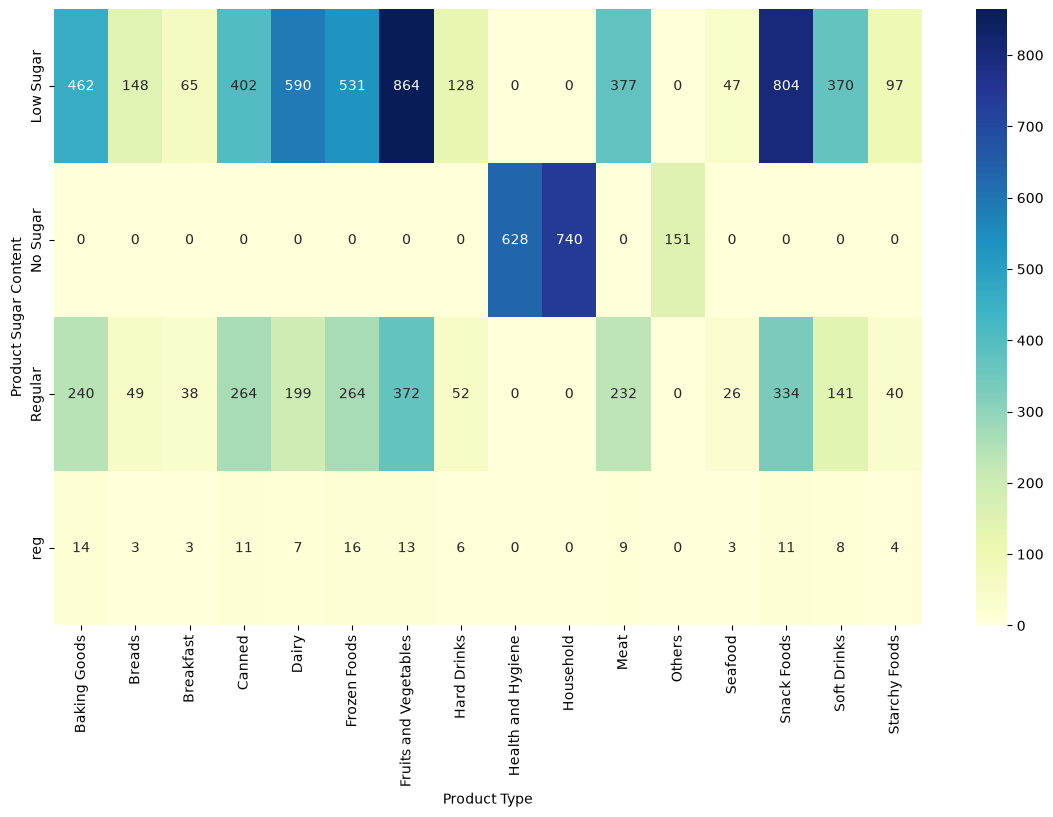

In [52]:
# Create a heatmap to visualize the relationship between Product Sugar Content 
# and Product Type.

plt.figure(figsize=(14, 8))

sns.heatmap(
    pd.crosstab(data["Product_Sugar_Content"], data["Product_Type"]),
    annot=True,
    fmt="g",
    cmap="YlGnBu",
)

plt.ylabel("Product Sugar Content")
plt.xlabel("Product Type")

plt.show()

### **Observations: Product Sugar Content vs Product Type**

* **Low Sugar** is the most common sugar content category across the majority of product types.

* **Fruits and Vegetables** and **Snack Foods** have the highest number of **Low Sugar** products, followed by **Dairy** and **Frozen Foods**.

* The **No Sugar** category is primarily associated with **Health and Hygiene**, **Household**, and **Others** product types, while it is absent in most food-related categories.

* **Regular** sugar content products are present across many product types but in lower numbers than **Low Sugar** products.

* The **'reg'** category contains very few observations across all product types, suggesting that it may represent inconsistent or incorrectly labeled data.

* Several product types contain only one or two sugar content categories, indicating that **Product Type and Product Sugar Content are not completely independent**.

* Overall, **Low Sugar dominates the dataset**, while **No Sugar** products are concentrated mainly in non-food product categories such as **Health and Hygiene** and **Household**.

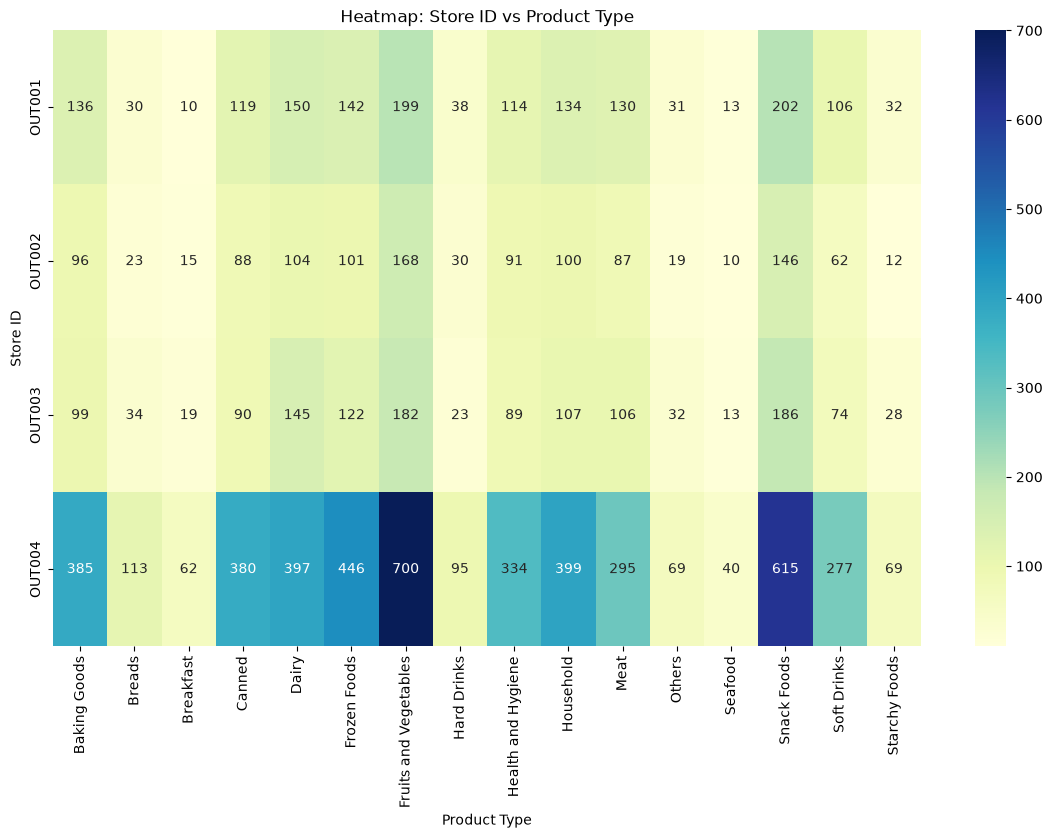

In [53]:
# Heatmap showing the distribution of Product Types across different Stores

plt.figure(figsize=(14, 8))

sns.heatmap(
    pd.crosstab(data["Store_Id"], data["Product_Type"]),
    annot=True,
    fmt="g",
    cmap="YlGnBu"      # You can also use Blues, crest, plasma, rocket
)

plt.title("Heatmap: Store ID vs Product Type")
plt.ylabel("Store ID")
plt.xlabel("Product Type")

plt.show()

### **Observation**

* **OUT004 stocks the highest number of products across almost every Product Type**, indicating that it is the largest and busiest store in the dataset.

* **Fruits and Vegetables** is the most frequently available product category across all stores, with OUT004 having the highest count (700).

* **Snack Foods** is another highly stocked category, especially in **OUT004** (615 products), followed by **OUT001** (202) and **OUT003** (186).

* **OUT001, OUT002, and OUT003 have relatively similar product distributions**, while **OUT004 consistently has much higher inventory levels** across nearly every category.

* Categories such as **Seafood, Others, Breakfast, and Starchy Foods** have comparatively fewer products in all stores.

* The heatmap suggests that **store inventory varies significantly by Store ID**, with **OUT004 maintaining a much wider product assortment than the other stores.**

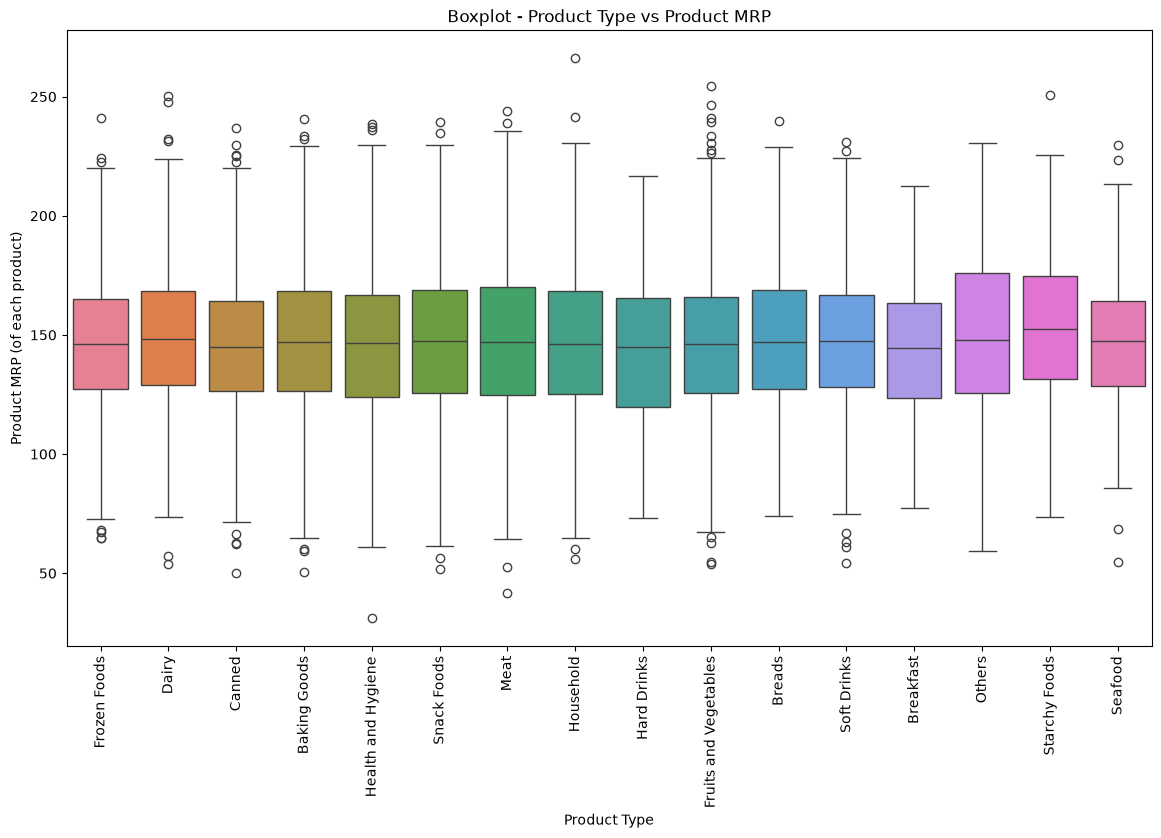

In [54]:
# Boxplot showing the distribution of Product MRP across different Product Types

plt.figure(figsize=[14, 8])

sns.boxplot(
    data=data,
    x="Product_Type",
    y="Product_MRP",
    hue="Product_Type"
)

plt.xticks(rotation=90)
plt.title("Boxplot - Product Type vs Product MRP")
plt.xlabel("Product Type")
plt.ylabel("Product MRP (of each product)")

plt.show()

### **Observation**

* **The median Product MRP is fairly similar across most Product Types**, indicating that products are generally priced within a comparable range.

* **Most product categories have a median MRP between approximately 140 and 155**, with only minor differences across categories.

* **The spread (IQR) of Product MRP is also similar for most Product Types**, suggesting consistent pricing variation within each category.

* Several Product Types contain **high-priced and low-priced outliers**, indicating that some products are priced significantly above or below the typical range.

* Categories such as **Others, Starchy Foods, and Dairy** exhibit slightly higher variability in Product MRP compared to some other product categories.

* Overall, **Product Type alone does not appear to be a strong differentiating factor for Product MRP**, as the distributions largely overlap across categories.

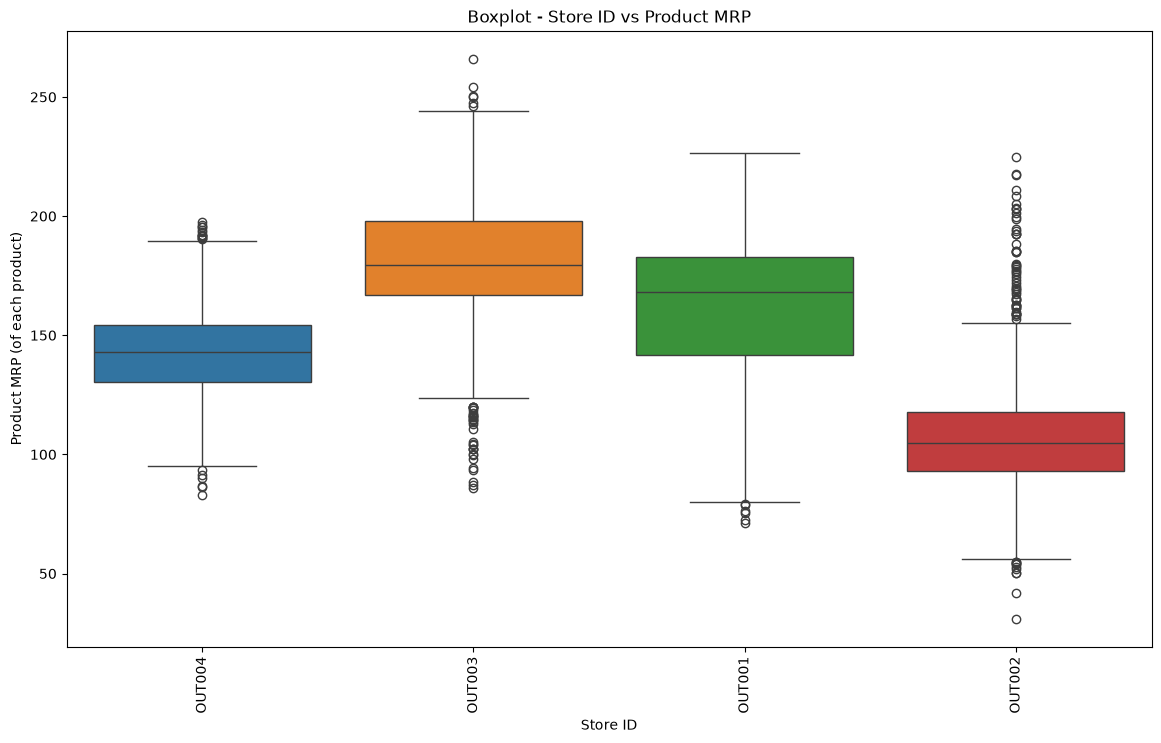

In [55]:
# Boxplot showing the distribution of Product MRP across different Stores

plt.figure(figsize=[14, 8])

sns.boxplot(
    data=data,
    x="Store_Id",
    y="Product_MRP",
    hue="Store_Id"
)

plt.xticks(rotation=90)
plt.title("Boxplot - Store ID vs Product MRP")
plt.xlabel("Store ID")
plt.ylabel("Product MRP (of each product)")

plt.show()

### **Observation**

* **Store OUT003 has the highest median Product MRP**, indicating that products sold in this store are generally priced higher than those in the other stores.

* **Store OUT002 has the lowest median Product MRP**, suggesting that it primarily stocks lower-priced products.

* **OUT001 and OUT004 have moderate median Product MRP values**, with most products falling within a similar price range.

* **OUT003 shows the widest spread in Product MRP**, indicating greater variation in product prices compared to the other stores.

* All stores contain **both high-priced and low-priced outliers**, showing that a few products are priced significantly above or below the typical range.

* The boxplot indicates that **Product MRP differs across stores**, suggesting that the product assortment and pricing strategy vary by Store ID.

In [56]:
# Calculate the total sales for each Product Type across different Stores
df1 = data.groupby(["Product_Type", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()

df1

,Product_Type,Store_Id,Product_Store_Sales_Total
0,Baking Goods,OUT001,525131.04
1,Baking Goods,OUT002,169860.50
2,Baking Goods,OUT003,491908.20
3,Baking Goods,OUT004,1266086.26
4,Breads,OUT001,121274.09
5,Breads,OUT002,43419.47
6,Breads,OUT003,175391.93
7,Breads,OUT004,374856.75
8,Breakfast,OUT001,38161.10
9,Breakfast,OUT002,23396.10


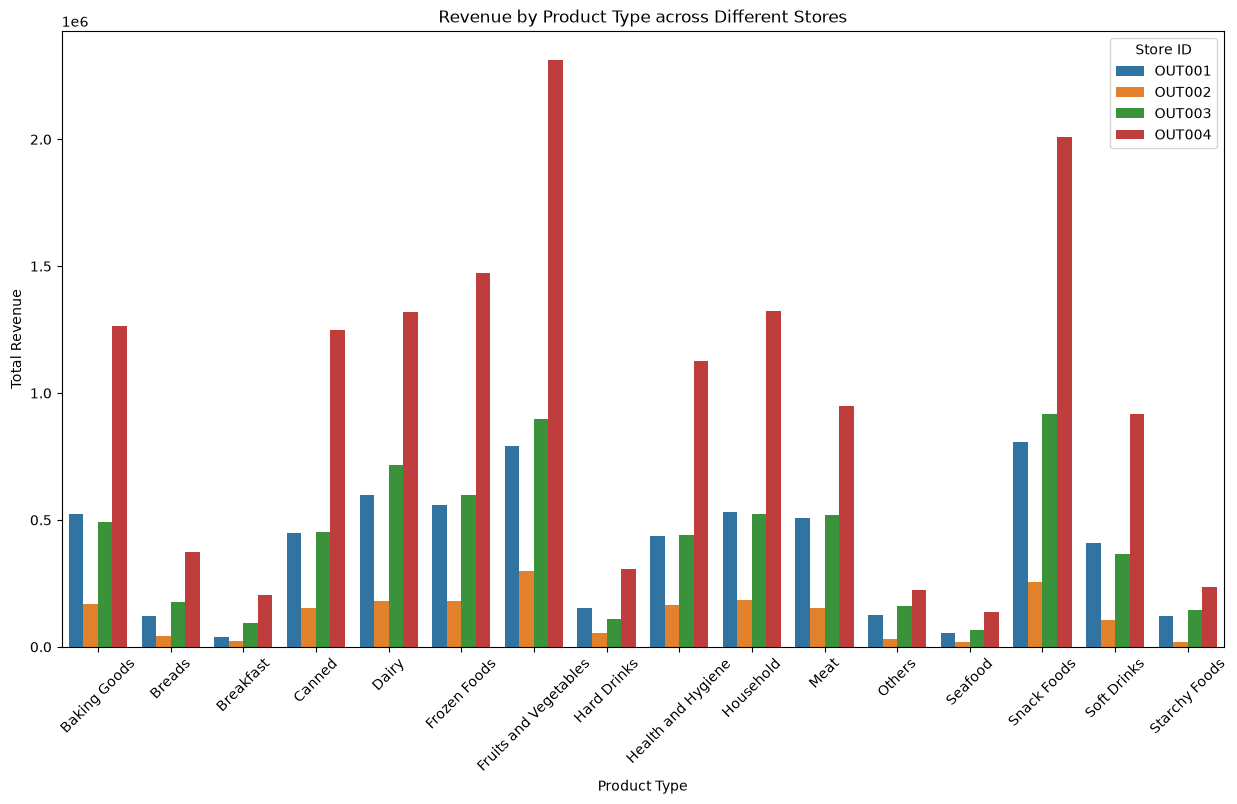

In [58]:
# Compare total revenue generated by each Product Type across different Stores.

plt.figure(figsize=(15, 8))

sns.barplot(
    data=df1,
    x="Product_Type",
    y="Product_Store_Sales_Total",
    hue="Store_Id"
)

plt.title("Revenue by Product Type across Different Stores")
plt.xlabel("Product Type")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.legend(title="Store ID")
plt.show()

### **Observation**

* **OUT004** generates the highest revenue across almost every product category, making it the best-performing store overall.

* **OUT002** consistently records the lowest revenue for most product categories.

* **Fruits and Vegetables** generate the highest revenue across all stores, followed by **Snack Foods**.

* **Dairy**, **Frozen Foods**, **Household**, and **Health and Hygiene** also contribute significantly to total revenue.

* **Breakfast**, **Seafood**, **Others**, and **Starchy Foods** contribute comparatively lower revenue across all stores.

* Although all stores sell similar product categories, the magnitude of revenue differs considerably, indicating that **Store ID has a strong influence on sales performance**.

* The sales pattern across product categories is fairly consistent, with high-selling categories remaining similar across different stores.

In [57]:
# Calculate the total sales for each Product Sugar Content category across different Stores
df2 = data.groupby(["Product_Sugar_Content", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()

df2

,Product_Sugar_Content,Store_Id,Product_Store_Sales_Total
0,Low Sugar,OUT001,3300834.93
1,Low Sugar,OUT002,1156758.85
2,Low Sugar,OUT003,3706903.24
3,Low Sugar,OUT004,8658908.78
4,No Sugar,OUT001,1090353.78
5,No Sugar,OUT002,382162.19
6,No Sugar,OUT003,1123084.57
7,No Sugar,OUT004,2674343.14
8,Regular,OUT001,1749444.51
9,Regular,OUT002,472112.50


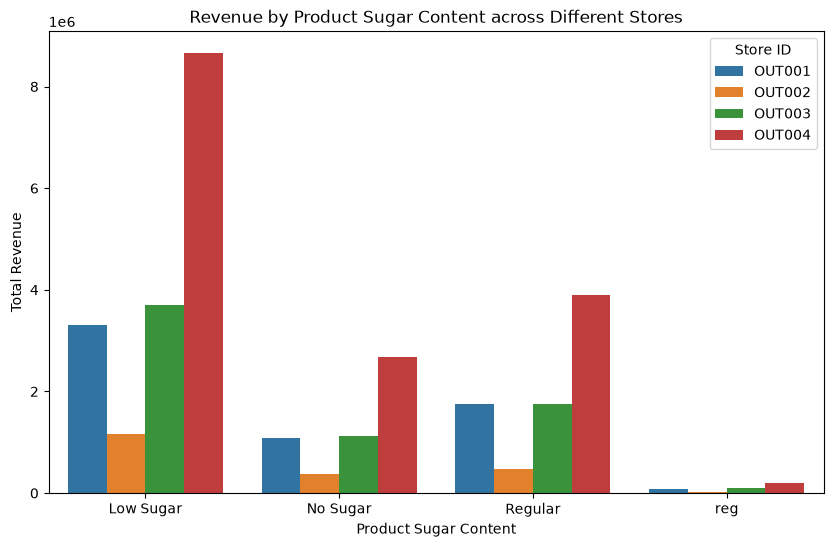

In [59]:
# Compare total revenue generated by each Product Sugar Content category across different Stores.

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df2,
    x="Product_Sugar_Content",
    y="Product_Store_Sales_Total",
    hue="Store_Id"
)

plt.title("Revenue by Product Sugar Content across Different Stores")
plt.xlabel("Product Sugar Content")
plt.ylabel("Total Revenue")

plt.legend(title="Store ID")
plt.show()

### **Observation**

* **OUT004** generates the highest revenue across all sugar content categories, outperforming the other stores by a significant margin.

* **Low Sugar** products contribute the highest revenue in every store, making them the most profitable sugar content category.

* **Regular** products generate the second-highest revenue across most stores.

* **No Sugar** products contribute moderate revenue and consistently perform below **Low Sugar** and **Regular** products.

* The **reg** category contributes very little revenue across all stores, suggesting it may represent a small product segment or a data quality issue (possible inconsistent labeling).

* **OUT002** records the lowest revenue across nearly every sugar content category.

* The overall revenue pattern is similar across stores, indicating that **Low Sugar products are consistently popular regardless of store location**.

# **Data Preprocessing**

The Exploratory Data Analysis (EDA) phase helped identify the characteristics of the dataset, including feature distributions, relationships between variables, and data quality issues. In this section, the dataset is prepared for machine learning by correcting inconsistencies, performing feature engineering, encoding categorical variables, and creating the final dataset for model training.

In [66]:
# Create a copy of the original dataset to preserve the raw data.

df = data.copy()

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8763, 12)


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [67]:
# Correct inconsistent category labels identified during Exploratory Data Analysis.

df["Product_Sugar_Content"] = df["Product_Sugar_Content"].replace({
    "reg": "Regular"
})

print(df["Product_Sugar_Content"].value_counts())

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64


### **Observation**

* During Exploratory Data Analysis, an inconsistent category label (**reg**) was identified in the **Product_Sugar_Content** feature.

* The inconsistent label has been standardized to **Regular**, improving data quality and ensuring consistent category representation during model training.

In [116]:
# Separate the predictor variables and the target variable.

X = df.drop(["Product_Store_Sales_Total", "Product_Id"], axis=1)

y = df["Product_Store_Sales_Total"]

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (8763, 10)
Target Variable Shape: (8763,)


### **Observation**

- The dataset has been divided into predictor variables (**X**) and the target variable (**y**).

- **Product_Id** has been excluded from the predictor variables because it is a unique identifier for each record and does not provide meaningful predictive information for the model.

- The remaining predictor variables contain the relevant product and store characteristics that will be used to train the machine learning models, while **Product_Store_Sales_Total** serves as the target variable for sales prediction.

In [117]:
# Identify numerical and categorical columns for preprocessing.

num_cols = X.select_dtypes(include=np.number).columns.tolist()

cat_cols = X.select_dtypes(include="object").columns.tolist()

print("Numerical Features:")
print(num_cols)

print("\nCategorical Features:")
print(cat_cols)

Numerical Features:
['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']

Categorical Features:
['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


### **Observation**

* The dataset contains both **numerical** and **categorical** features.

* Numerical variables will be used directly during model training, whereas categorical variables will be transformed using encoding techniques before being fed into the machine learning models.

## Data Preprocessing Summary

The following preprocessing steps have been completed before model building:

* Missing values were handled.
* Inconsistent category labels were corrected.
* Predictor and target variables were separated.
* Numerical and categorical features were identified.
* The dataset was split into training and testing sets.
* A preprocessing pipeline was created using StandardScaler and OneHotEncoder.
* The transformed datasets are now ready for machine learning models.

## Feature Preparation for Machine Learning

In this section, the predictor variables are transformed into a format suitable for machine learning. Numerical features are standardized, categorical features are encoded, and the data is split into training and testing sets. A preprocessing pipeline is also created to ensure consistent data transformation during model training and evaluation.

In [119]:
# Split the dataset into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)
print("Training Target Shape  :", y_train.shape)
print("Testing Target Shape   :", y_test.shape)

Training Feature Shape : (7010, 10)
Testing Feature Shape  : (1753, 10)
Training Target Shape  : (7010,)
Testing Target Shape   : (1753,)


### **Observation**

* The dataset has been divided into **80% training data** and **20% testing data**.

* The training data will be used to train and tune the machine learning models, while the testing data will be used to evaluate the final model's performance on unseen data.

In [120]:
# Create preprocessing pipelines for numerical and categorical features.

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = make_column_transformer(
    (numeric_transformer, num_cols),
    (categorical_transformer, cat_cols),
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

### **Observation**

* Numerical features are standardized using **StandardScaler** to ensure they are on a comparable scale.

* Categorical variables are transformed into numerical format using **One-Hot Encoding**, enabling machine learning algorithms to process them effectively.

* A preprocessing pipeline has been created to apply identical transformations to both the training and testing datasets, ensuring consistency and preventing data leakage.

In [121]:
# Fit the preprocessing pipeline on the training data and transform both training and testing datasets.

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape :", X_train_processed.shape)
print("Processed Testing Shape  :", X_test_processed.shape)

Processed Training Shape : (7010, 37)
Processed Testing Shape  : (1753, 37)


### **Observation**

* The preprocessing pipeline has successfully transformed the training and testing datasets into a machine learning-ready format.

* Numerical features have been standardized, while categorical features have been encoded into numerical variables.

* The processed datasets are now ready for training and evaluating regression models.

## Data Preparation Complete

The dataset has now been cleaned, transformed, and prepared for machine learning. All numerical variables have been standardized, categorical variables have been encoded, and the data has been split into training and testing sets. The processed datasets are now ready for model development and evaluation.

# **Model Building**

## Define functions for Model Evaluation

In [122]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

# ## Model Building

According to the project rubric, **any two machine learning regression models** can be selected from the six models provided in this notebook. For this project, **Random Forest Regressor** and **XGBoost Regressor** have been selected because they are powerful ensemble learning algorithms that perform exceptionally well on structured tabular datasets and are capable of capturing complex non-linear relationships.

The selected models will first be trained using their default parameters to establish a baseline performance. Their performance will then be improved through **hyperparameter tuning** using **GridSearchCV**.

Model performance will be evaluated using multiple regression metrics, including **R-squared**, **Adjusted R-squared**, **RMSE**, **MAE**, and **MAPE**. The model demonstrating the best overall performance on the testing dataset will be selected as the final model for deployment.


Random Forest was selected as a robust baseline ensemble model, while XGBoost was chosen because of its ability to achieve high predictive accuracy through gradient boosting and regularization techniques.

### **Random Forest Regressor**

Random Forest is an ensemble learning algorithm that combines the predictions of multiple decision trees to improve prediction accuracy and reduce overfitting. It is robust, handles non-linear relationships effectively, and performs exceptionally well on structured datasets.

In [123]:
# Build a baseline Random Forest Regressor.

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Product_Weight','Product_Sugar_Content','Product_Allocated_Area',..., 'Store_Size','Store_Location_City_Type','Store_Type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedt

In [124]:
# Evaluate the Random Forest model on the training dataset.

rf_train_perf = model_performance_regression(
    rf_model,
    X_train,
    y_train
)

rf_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,107.304755,40.45579,0.989847,0.989832,0.015129


In [125]:
# Evaluate the Random Forest model on the testing dataset.

rf_test_perf = model_performance_regression(
    rf_model,
    X_test,
    y_test
)

rf_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,283.381773,109.006192,0.92962,0.929216,0.038868


In [126]:
#Compare Train vs Test
rf_compare = pd.concat(
    [
        rf_train_perf.assign(Data="Train"),
        rf_test_perf.assign(Data="Test")
    ]
)

rf_compare

,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Data
0,107.304755,40.455790,0.989847,0.989832,0.015129,Train
0,283.381773,109.006192,0.929620,0.929216,0.038868,Test


### **Observation**

- The baseline **Random Forest Regressor** achieved strong predictive performance on both the training and testing datasets.

- The model explains approximately **99.0%** of the variance in the training data and **93.0%** of the variance in the testing data, indicating excellent predictive capability.

- The training performance is slightly better than the testing performance, suggesting **minor overfitting**, but the model still demonstrates good generalization to unseen data.

- The **RMSE, MAE, and MAPE** values indicate that the model makes accurate predictions with relatively low prediction errors. Although removing **Product_Id** resulted in a slight decrease in performance, the model is now more robust because it relies on meaningful product and store characteristics rather than a unique identifier.

### **Hyperparameter Tuning - Random Forest Regressor**

Although the baseline Random Forest model achieved strong predictive performance, its hyperparameters can be optimized to improve generalization on unseen data. Hyperparameter tuning is performed using **GridSearchCV** with **5-fold cross-validation**, allowing multiple parameter combinations to be evaluated systematically. The best-performing combination is selected based on the **R-squared** score.

In [127]:
# Define the parameter grid for Random Forest hyperparameter tuning.

param_grid_rf = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [15, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5],
}

In [128]:
# Perform hyperparameter tuning using GridSearchCV.

grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [15, 20, ...], 'model__max_features': ['sqrt', 0.5], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevalu

In [129]:
# Display the best hyperparameters.

print("Best Parameters:")
print(grid_search_rf.best_params_)

print("\nBest Cross-Validation R² Score:")
print(grid_search_rf.best_score_)

Best Parameters:
{'model__max_depth': 20, 'model__max_features': 0.5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 500}

Best Cross-Validation R² Score:
0.9278527227570258


max_features = 0.5 means that each decision tree considers 50% of the available features at every split. This increases diversity among the trees, helping reduce overfitting while maintaining strong predictive performance.

In [130]:
# Retrieve the best Random Forest model.

best_rf = grid_search_rf.best_estimator_

In [131]:
# Evaluate the tuned Random Forest model on the training dataset.

rf_train_tuned = model_performance_regression(
    best_rf,
    X_train,
    y_train
)

rf_train_tuned

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,184.367947,69.288477,0.970026,0.969983,0.027061


In [132]:
# Evaluate the tuned Random Forest model on the testing dataset.

rf_test_tuned = model_performance_regression(
    best_rf,
    X_test,
    y_test
)

rf_test_tuned

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,278.92449,113.60709,0.931816,0.931425,0.042131


In [133]:
# Compare the tuned model's performance on the training and testing datasets.

rf_tuned_compare = pd.concat(
    [
        rf_train_tuned.assign(Data="Train"),
        rf_test_tuned.assign(Data="Test")
    ]
)

rf_tuned_compare

,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Data
0,184.367947,69.288477,0.970026,0.969983,0.027061,Train
0,278.924490,113.607090,0.931816,0.931425,0.042131,Test


### **Observation**

- The tuned Random Forest Regressor achieved strong predictive performance on both the training and testing datasets.

- The model explains approximately **97.0%** of the variance in the training data and **93.2%** of the variance in the testing data, indicating excellent predictive capability.

- Although the training performance is slightly higher than the testing performance, the reduced gap between the two suggests that hyperparameter tuning successfully reduced overfitting and improved the model's ability to generalize to unseen data.

- The relatively low **RMSE, MAE, and MAPE** values indicate that the tuned model continues to make accurate predictions while maintaining better generalization than the baseline model.

In [134]:
# Compare the baseline and tuned Random Forest models on the test dataset.

rf_model_comparison = pd.concat(
    [
        rf_test_perf.assign(Model="Baseline Random Forest"),
        rf_test_tuned.assign(Model="Tuned Random Forest")
    ],
    ignore_index=True
)

rf_model_comparison = rf_model_comparison[
    ["Model", "RMSE", "MAE", "R-squared", "Adj. R-squared", "MAPE"]
]

rf_model_comparison

,Model,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,Baseline Random Forest,283.381773,109.006192,0.929620,0.929216,0.038868
1,Tuned Random Forest,278.924490,113.607090,0.931816,0.931425,0.042131


### **Observation**

- Hyperparameter tuning resulted in a slight improvement in the **R-squared** value on the test dataset, increasing it from **92.96%** to **93.18%**, indicating better predictive performance.

- The tuned model achieved a slightly lower **RMSE**, demonstrating a reduction in overall prediction error compared to the baseline model.

- Although the **MAE** and **MAPE** increased marginally, the improvement in **R-squared** and **RMSE**, along with the reduction in overfitting, indicates that the tuned model generalizes better to unseen data.

- Therefore, the **tuned Random Forest Regressor** has been selected as the final Random Forest model for comparison with the second machine learning model.

### **XGBoost Regressor**

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that builds decision trees sequentially, where each new tree corrects the errors made by previous trees. It is known for its high predictive accuracy, regularization capabilities, and efficient handling of structured tabular datasets.

In [135]:
from xgboost import XGBRegressor

In [136]:
# Build a baseline XGBoost Regressor.

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                random_state=42,
                objective="reg:squarederror"
            )
        )
    ]
)

xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Product_Weight','Product_Sugar_Content','Product_Allocated_Area',..., 'Store_Size','Store_Location_City_Type','Store_Type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedt

In [137]:
# Evaluate the baseline XGBoost model on the training dataset.

xgb_train_perf = model_performance_regression(
    xgb_model,
    X_train,
    y_train
)

xgb_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,132.873337,62.735069,0.984431,0.984409,0.022233


In [138]:
# Evaluate the baseline XGBoost model on the testing dataset.

xgb_test_perf = model_performance_regression(
    xgb_model,
    X_test,
    y_test
)

xgb_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,310.109498,137.521286,0.915718,0.915234,0.050988


In [139]:
# Compare the baseline model's performance on the training and testing datasets.

xgb_compare = pd.concat(
    [
        xgb_train_perf.assign(Data="Train"),
        xgb_test_perf.assign(Data="Test")
    ]
)

xgb_compare

,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Data
0,132.873337,62.735069,0.984431,0.984409,0.022233,Train
0,310.109498,137.521286,0.915718,0.915234,0.050988,Test


### **Observation**

- The baseline XGBoost Regressor achieved strong predictive performance on both the training and testing datasets.

- The model explains approximately **98.4%** of the variance in the training data and **91.6%** of the variance in the testing data, indicating good predictive capability.

- The difference between the training and testing R-squared values suggests **slight overfitting**, although the model still generalizes reasonably well to unseen data.

- The relatively low **RMSE, MAE, and MAPE** values indicate that the model provides accurate sales predictions with acceptable prediction errors.

- Since there is still scope to improve generalization performance, hyperparameter tuning will be performed to determine whether the predictive performance can be further enhanced.

### **Hyperparameter Tuning - XGBoost Regressor**

To further improve the predictive performance of the XGBoost model, hyperparameter tuning is performed using **GridSearchCV** with **5-fold cross-validation**. Multiple combinations of model parameters are evaluated to identify the configuration that provides the best generalization performance on unseen data.

In [140]:
# Define the parameter grid for XGBoost hyperparameter tuning.

param_grid_xgb = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
}

In [141]:
# Perform hyperparameter tuning using GridSearchCV.

grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=0
)

grid_search_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.2

In [142]:
# Display the best hyperparameters.

print("Best Parameters:")
print(grid_search_xgb.best_params_)

print("\nBest Cross-Validation R² Score:")
print(grid_search_xgb.best_score_)

Best Parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__min_child_weight': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}

Best Cross-Validation R² Score:
0.9278466572205089


In [143]:
# Retrieve the best XGBoost model.

best_xgb = grid_search_xgb.best_estimator_

In [144]:
# Evaluate the tuned XGBoost model on the training dataset.

xgb_train_tuned = model_performance_regression(
    best_xgb,
    X_train,
    y_train,
)

xgb_train_tuned

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,229.798962,90.231467,0.953434,0.953368,0.034025


In [145]:
# Evaluate the tuned XGBoost model on the testing dataset.

xgb_test_tuned = model_performance_regression(
    best_xgb,
    X_test,
    y_test,
)

xgb_test_tuned

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,280.473191,114.026907,0.931057,0.930661,0.041385


In [146]:
# Compare the tuned model's performance on the training and testing datasets.

xgb_tuned_compare = pd.concat(
    [
        xgb_train_tuned.assign(Data="Train"),
        xgb_test_tuned.assign(Data="Test"),
    ]
)

xgb_tuned_compare

,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Data
0,229.798962,90.231467,0.953434,0.953368,0.034025,Train
0,280.473191,114.026907,0.931057,0.930661,0.041385,Test


### **Observation**

- The tuned XGBoost Regressor achieved strong predictive performance on both the training and testing datasets after hyperparameter optimization.

- The model explains approximately **95.3%** of the variance in the training data and **93.1%** of the variance in the testing data, demonstrating excellent predictive capability.

- Compared with the baseline XGBoost model, the gap between the training and testing R-squared values has reduced considerably, indicating that hyperparameter tuning successfully reduced overfitting and improved the model's ability to generalize to unseen data.

- The relatively low **RMSE, MAE, and MAPE** values indicate that the tuned model produces accurate sales predictions while maintaining a better balance between model complexity and predictive performance.

In [147]:
# Compare the baseline and tuned XGBoost models on the test dataset.

xgb_model_comparison = pd.concat(
    [
        xgb_test_perf.assign(Model="Baseline XGBoost"),
        xgb_test_tuned.assign(Model="Tuned XGBoost")
    ],
    ignore_index=True
)

xgb_model_comparison = xgb_model_comparison[
    ["Model", "RMSE", "MAE", "R-squared", "Adj. R-squared", "MAPE"]
]

xgb_model_comparison

,Model,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,Baseline XGBoost,310.109498,137.521286,0.915718,0.915234,0.050988
1,Tuned XGBoost,280.473191,114.026907,0.931057,0.930661,0.041385


### **Observation**

- Hyperparameter tuning significantly improved the performance of the XGBoost Regressor on the test dataset.

- The tuned model increased the **R-squared** value from **91.57%** to **93.11%**, indicating improved predictive capability.

- The tuned model achieved lower **RMSE**, **MAE**, and **MAPE** values than the baseline model, demonstrating a noticeable reduction in prediction errors.

- The cross-validation **R-squared** score of approximately **0.928** further confirms that the tuned model is robust and capable of generalizing well to unseen data.

- Therefore, the **tuned XGBoost Regressor** has been selected as the final XGBoost model for comparison with the tuned Random Forest Regressor.

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [148]:
# Compare the final tuned models.

final_model_comparison = pd.concat(
    [
        rf_test_tuned.assign(Model="Random Forest"),
        xgb_test_tuned.assign(Model="XGBoost"),
    ]
)

final_model_comparison = final_model_comparison[
    ["Model", "RMSE", "MAE", "R-squared", "Adj. R-squared", "MAPE"]
]

final_model_comparison

,Model,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,Random Forest,278.924490,113.607090,0.931816,0.931425,0.042131
0,XGBoost,280.473191,114.026907,0.931057,0.930661,0.041385


### **Observation**

- Both the tuned Random Forest Regressor and tuned XGBoost Regressor achieved excellent predictive performance on the test dataset after hyperparameter tuning.

- The Random Forest model achieved a slightly higher **R-squared (93.18%)** and lower **RMSE (278.92)** and **MAE (113.61)** than the XGBoost model, indicating marginally better overall predictive performance.

- The tuned XGBoost model achieved a slightly lower **MAPE (4.14%)** than the Random Forest model (4.21%), showing comparable prediction accuracy.

- Since the Random Forest Regressor produced the highest R-squared while maintaining the lowest overall prediction error, it provides the best balance between accuracy and generalization.

- Therefore, the **tuned Random Forest Regressor** has been selected as the final model for serialization and deployment.

## **Serialize the Best Model**

In [149]:
import joblib

# Save the final Random Forest model.

joblib.dump(best_rf, "random_forest_sales_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [150]:
# Load the saved model.

loaded_model = joblib.load("random_forest_sales_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


In [151]:
# Make predictions using the loaded model.

loaded_predictions = loaded_model.predict(X_test)

loaded_predictions[:10]

array([3346.68796399, 3352.35041704, 2421.75770562, 1942.68104145,
       4639.05914353, 2922.34002206, 2863.7164166 , 3167.034542  ,
       3280.81345225, 1547.20727105])

In [152]:
# Evaluate the loaded model.

loaded_model_perf = model_performance_regression(
    loaded_model,
    X_test,
    y_test,
)

loaded_model_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,278.92449,113.60709,0.931816,0.931425,0.042131


### **Comparison of Original and Serialized Model**

To verify that the model serialization process preserved the trained model correctly, the performance of the original Random Forest model is compared with the performance of the loaded (serialized) model on the test dataset.

In [153]:
# Compare the performance of the original and serialized Random Forest models.

serialized_comparison = pd.concat(
    [
        rf_test_tuned.assign(Model="Original Random Forest"),
        loaded_model_perf.assign(Model="Serialized Random Forest"),
    ]
)

serialized_comparison = serialized_comparison[
    ["Model", "RMSE", "MAE", "R-squared", "Adj. R-squared", "MAPE"]
]

serialized_comparison

,Model,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,Original Random Forest,278.92449,113.60709,0.931816,0.931425,0.042131
0,Serialized Random Forest,278.92449,113.60709,0.931816,0.931425,0.042131


### **Observation**

* The performance metrics of the serialized Random Forest model are identical to those of the original trained model.

* This confirms that the model was successfully saved and loaded without any loss of information or predictive capability.

* Model serialization enables the trained model to be deployed and reused for future predictions without requiring retraining.

# **Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account if you don't already have one at [github.com](https://github.com)
- Generate a **Personal Access Token**
  - Make sure the token has **repo** scope (full control of private repositories)
- The serialized ML model file (`superkart_model.joblib`) should already be present in the `backend_files` folder before pushing to GitHub
- We will deploy **both the Flask backend and the Streamlit frontend as separate Docker containers** inside a GitHub Codespace, and connect them using a **Docker network**

## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

In [155]:
import os

os.makedirs("backend_files", exist_ok=True)

In [157]:
import shutil

shutil.copy(
    "random_forest_sales_model.pkl",
    "backend_files/random_forest_sales_model.pkl"
)

print("Model copied successfully!")

Model copied successfully!


In [158]:
print(os.listdir("backend_files"))

['random_forest_sales_model.pkl']


In [159]:
%%writefile backend_files/app.py

import joblib
import pandas as pd
from flask import Flask, request, jsonify

superkart_api = Flask("SuperKart")

# Load the trained Random Forest model
model = joblib.load("random_forest_sales_model.pkl")


@superkart_api.get("/")
def home():
    return "Welcome to the SuperKart Sales Prediction API"


@superkart_api.post("/v1/predict")
def predict_sales():

    data = request.get_json()

    sample = {
        "Product_Weight": data["Product_Weight"],
        "Product_Sugar_Content": data["Product_Sugar_Content"],
        "Product_Allocated_Area": data["Product_Allocated_Area"],
        "Product_Type": data["Product_Type"],
        "Product_MRP": data["Product_MRP"],
        "Store_Id": data["Store_Id"],
        "Store_Establishment_Year": data["Store_Establishment_Year"],
        "Store_Size": data["Store_Size"],
        "Store_Location_City_Type": data["Store_Location_City_Type"],
        "Store_Type": data["Store_Type"],
    }

    input_df = pd.DataFrame([sample])

    prediction = model.predict(input_df)[0]

    return jsonify({"Predicted Sales": float(prediction)})


@superkart_api.post("/v1/predictbatch")
def predict_batch():

    file = request.files["file"]

    input_df = pd.read_csv(file)

    predictions = model.predict(input_df)

    return {
        str(i): round(float(pred), 2)
        for i, pred in enumerate(predictions)
    }


if __name__ == "__main__":
    superkart_api.run(debug=True)

Writing backend_files/app.py


## Dependencies File

In [160]:
%%writefile backend_files/requirements.txt

flask
gunicorn
pandas
numpy
scikit-learn
xgboost
joblib

Writing backend_files/requirements.txt


## **DOKERFILE**

In [161]:
%%writefile backend_files/Dockerfile

FROM python:3.11-slim

WORKDIR /app

COPY . .

RUN pip install --no-cache-dir -r requirements.txt

EXPOSE 5000

CMD ["gunicorn", "--bind", "0.0.0.0:5000", "app:superkart_api"]

Writing backend_files/Dockerfile


# **Deployment - Frontend**

## Streamlit for Interactive UI

In [162]:
%%writefile frontend.py

import streamlit as st
import requests

st.title("SuperKart Sales Prediction")

product_weight = st.number_input("Product Weight")
product_sugar_content = st.selectbox(
    "Product Sugar Content",
    ["Low Sugar", "Regular", "No Sugar"]
)

product_allocated_area = st.number_input("Product Allocated Area")

product_type = st.selectbox(
    "Product Type",
    [
        "Dairy",
        "Soft Drinks",
        "Meat",
        "Fruits and Vegetables",
        "Household",
        "Baking Goods",
        "Snack Foods",
        "Frozen Foods",
        "Breakfast",
        "Health and Hygiene",
        "Hard Drinks",
        "Canned",
        "Breads",
        "Starchy Foods",
        "Others",
        "Seafood"
    ]
)

product_mrp = st.number_input("Product MRP")

store_id = st.selectbox(
    "Store Id",
    [
        "OUT010","OUT013","OUT017","OUT018",
        "OUT019","OUT027","OUT035","OUT045",
        "OUT046","OUT049"
    ]
)

store_establishment_year = st.number_input("Store Establishment Year")

store_size = st.selectbox(
    "Store Size",
    ["Small", "Medium", "High"]
)

store_location_city_type = st.selectbox(
    "Store Location City Type",
    ["Tier 1", "Tier 2", "Tier 3"]
)

store_type = st.selectbox(
    "Store Type",
    [
        "Supermarket Type1",
        "Supermarket Type2",
        "Supermarket Type3",
        "Grocery Store"
    ]
)

if st.button("Predict Sales"):

    payload = {
        "Product_Weight": product_weight,
        "Product_Sugar_Content": product_sugar_content,
        "Product_Allocated_Area": product_allocated_area,
        "Product_Type": product_type,
        "Product_MRP": product_mrp,
        "Store_Id": store_id,
        "Store_Establishment_Year": store_establishment_year,
        "Store_Size": store_size,
        "Store_Location_City_Type": store_location_city_type,
        "Store_Type": store_type
    }

    response = requests.post(
        "http://127.0.0.1:5000/v1/predict",
        json=payload
    )

    st.success(response.json())

Writing frontend.py


## Dependencies File

In [163]:
%%writefile frontend_requirements.txt

streamlit
requests

Writing frontend_requirements.txt


## Dockerfile

In [164]:
%%writefile frontend_Dockerfile

FROM python:3.11-slim

WORKDIR /app

COPY . .

RUN pip install --no-cache-dir -r frontend_requirements.txt

EXPOSE 8501

CMD ["streamlit", "run", "frontend.py", "--server.port=8501", "--server.address=0.0.0.0"]

Writing frontend_Dockerfile


# **Pushing Deployment Files to GitHub**

# **Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the deployed Flask API running inside a GitHub Codespace to perform **online** and **batch inference** from this Colab notebook.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running the cells below**, make sure:
- Your Codespace is running with both containers up
- Port 7860 has been set to **Public** in the Codespace Ports tab
- You have copied the forwarded URL for port 7860
- You have also referred the document titled **`Guided Hands-on - Containerized Model Deployment using GitHub Codespaces`** provided

In [ ]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [ ]:
model_root_url = "_____"  # Complete the code to replace with your Codespace forwarded URL for port 7860

Replace the URL above with the actual forwarded URL from your Codespace's Ports tab. It will look something like `https://organic-space-abcd1234-7860.app.github.dev`. Make sure there is no trailing slash at the end.

This URL is a tunnel that Codespaces creates to route external HTTP requests into your Codespace and to the Flask container running on port 7860.

In [ ]:
model_url = model_root_url + "/v1/predict"  # Endpoint for online (single) inference

Since our model predictions are provided by the following endpoint we created using Flask, we need to invoke the same to make prediction.

> ```@superkart_api.post('/v1/predict')```

In [ ]:
model_batch_url = model_root_url + "/v1/predictbatch"  # Endpoint for batch inference

> ```@superkart_api.post('/v1/predictbatch')```

## Online

**Online Inference:** Sending a single request to the API and receiving an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.  
* This data is sent as a JSON payload in a POST request to the model endpoint.

* The model processes the input features and returns a prediction.

In [ ]:
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

In [ ]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [ ]:
response

`<Response [200]>` indicates that the HTTP request was successful.  

- `Response` is the object returned by `requests.post()`.  
- `[200]` is the HTTP status code, meaning **OK** (the request was processed successfully).  

In [ ]:
print(response.json())

`response.json()` is used to parse the response body as JSON.  
- If the API returns data in JSON format, `.json()` converts it into a Python dictionary.  
- This allows easy access to specific values using keys.  

## Batch

**Batch Inference:** Sending multiple inputs in a single request, allowing efficient processing of large datasets. This is ideal for analyzing historical data at scale.

In [ ]:
batch_dataset = pd.read_csv("Batch_Data_SuperKart.csv")

**Note**: The batch CSV file must contain all the feature columns expected by the model: `Product_Weight`, `Product_Sugar_Content`, `Product_Allocated_Area`, `Product_MRP`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`, `Product_Id_char`, `Store_Age_Years`, `Product_Type_Category`.

In [ ]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

This code prepares the product data as a **file-like object** to send in an API request (in the `files` parameter of `requests.post`).

- `batch_dataset`: This is a Pandas DataFrame containing the product data loaded from a CSV file.

- `.to_csv(header=True, index=False)`: Converts the DataFrame into a CSV **string**, keeping the column headers (`header=True`) but **excluding the index** (`index=False`).

- `.encode('utf-8')`: Encodes the CSV string into **bytes** (UTF-8 format), which is necessary for sending it over an HTTP request.

- `'file': ...`: Wraps the encoded CSV data in a dictionary with the key `'file'`, which is expected by the Flask backend.

In [ ]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

This line sends a **POST request** to the deployed model API to perform **batch sales prediction**.

- `requests.post(...)`: This uses the `requests` library to make a **POST** request to a web server (in this case, our API endpoint for batch predictions).

- `model_batch_url`: This is the URL endpoint where the batch prediction API is hosted. It should look like this:\
  `"https://<your-codespace-name>-7860.app.github.dev/v1/predictbatch"`

- `files=batch_input`: This sends the batch data file (e.g., a CSV) as part of the request using the `files` parameter.

- `response`: This is the result of the API call and contains the response from the server, including predicted sales values.

In [ ]:
response

In [ ]:
# Extract predictions from API response
response.text

As we can see, we receive a JSON where each key represents a row index, and the value represents the model's predicted sales for that product.

# **Actionable Insights and Business Recommendations**

-

-